# Sistema masa resorte amortiguador

Un **sistema masa resorte amortiguador** consta de tres componentes esenciales

| Componente | Símbolo | Función | Ejemplo en el mundo real |
| --- | --- | --- | --- |
| **Masa** | $m$ | Proporciona inercia | Carrocería de un auto en suspensión |
| **Resorte** | $k$ | Proporciona fuerza restauradora | Resorte de un amortiguador |
| **Amortiguador** | $c$ | Disipa energía | Fluido del amortiguador |

## Modelo Matemático

### Ecuación diferencial gobernante

El sistema se rige por la segunda Ley de Newton

\begin{equation}
 m\frac{d^2x}{dt^2} + c\frac{dx}{dt} + kx = 0,
\end{equation}

donde
* $x(t)$: Desplazamiento desde la posición de equilibrio [m].
* $\dot{x}(t)$: Velocidad [m/s].
* $\ddot{x}(t)$: Aceleración [m/s$^2$].
* $m$: Masa [kg].
* $c$: Coeficiente de amortiguamiento [N$\cdot$s/m].
* $k$: Constante del resorte [N/m].

### Parámetros adimensionales

**Frecuencia Natural**

\begin{equation}
 \omega_n = \sqrt{\frac{k}{m}} \quad \text{[rad/s]}.
\end{equation}

**Razón de Amortiguamiento**

\begin{equation}
 \zeta = \frac{c}{2\sqrt{km}}.
\end{equation}

**Frecuencia Natural Amortiguada**

\begin{equation}
 \omega_d = \omega_n\sqrt{1-\zeta^2} \quad \text{(para } \zeta < 1\text{)}.
\end{equation}

### Ecuación característica del sistema

Al sustituir $x(t) = e^{\lambda t}$ se obtiene:

\begin{equation}
 m\lambda^2 + c\lambda + k = 0,
\end{equation}

cuyas raíces están dadas como sigue

\begin{equation}
 \lambda_{1,2} = -\frac{c}{2m} \pm \sqrt{\left(\frac{c}{2m}\right)^2 - \frac{k}{m}}.
\end{equation}

## Tipos de solución según la razón de amortiguamiento

### Sistema no amortiguado ($\zeta = 0$)

\begin{equation}
 x(t) = A\cos(\omega_n t) + B\sin(\omega_n t).
\end{equation}

* Oscilación sinusoidal pura.
* Amplitud constante.
* Sin disipación de energía.

### Sistema subamortiguado ($0 < \zeta < 1$)

\begin{equation}
 x(t) = e^{-\zeta\omega_n t}\left[A\cos(\omega_d t) + B\sin(\omega_d t)\right].
\end{equation}

* Movimiento oscilatorio.
* Amplitud con decaimiento exponencial.
* Caso más común en aplicaciones prácticas.

### Sistema con amortiguamiento crítico ($\zeta = 1$)

\begin{equation}
 x(t) = (A + Bt)e^{-\omega_n t}.
\end{equation}

* Regreso más rápido al equilibrio sin oscilación.
* Amortiguamiento mínimo para evitar el sobrepaso (*overshoot*).

### Sistema sobreamortiguado ($\zeta > 1$)

\begin{equation}
 x(t) = Ae^{\lambda_1 t} + Be^{\lambda_2 t}.
\end{equation}

* Movimiento no oscilatorio.
* Regreso al equilibrio más lento que en el amortiguamiento crítico.

## Interpretación Física

### Balance de Energía
**Energía Total = Energía Cinética + Energía Potencial + Energía Disipada**

\begin{equation}
 E(t) = \underbrace{\frac{1}{2}m\dot{x}^2}_{\text{Cinética}} + \underbrace{\frac{1}{2}kx^2}_{\text{Potencial}} + \underbrace{\int_0^t c\dot{x}^2\,dt}_{\text{Disipada}}
\end{equation}

El amortiguador convierte continuamente la energía mecánica en calor.

### Componentes de Fuerza
1. **Fuerza de inercia**: $F_m = m\ddot{x}$.
2. **Fuerza de amortiguamiento**: $F_c = c\dot{x}$ (se opone al movimiento).
3. **Fuerza del resorte**: $F_k = kx$ (fuerza restauradora).

`````{admonition} Ideas clave
* La **razón de amortiguamiento** $\zeta$ determina el comportamiento del sistema.
* El **amortiguamiento crítico** proporciona la respuesta no oscilatoria más rápida.
* La mayoría de los sistemas mecánicos son **subamortiguados** ($0.05 < \zeta < 0.7$).
* El método del **decremento logarítmico** permite determinar $\zeta$ experimentalmente a partir del decaimiento de la oscilación.
`````

### Ejemplo de Parámetros de Simulación

| Parámetro | Valor Típico | Unidad |
| --- | --- | --- |
| Masa ($m$) | 1.0 | kg |
| Constante del Resorte ($k$) | 10.0 | N/m |
| Coeficiente de Amortiguamiento ($c$) | 0.5, 2.0, 5.0 | $\text{N}\cdot\text{s/m}$ |
| Desplazamiento Inicial ($x_0$) | 1.0 | m |
| Velocidad Inicial ($v_0$) | 0.0 | m/s |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy
from scipy.optimize import curve_fit
from scipy.integrate import solve_ivp
from scipy.stats import linregress
from scipy.signal import find_peaks
from scipy.optimize import minimize_scalar
from scipy.optimize import minimize, differential_evolution
from scipy.optimize import differential_evolution
from sklearn.metrics import mean_squared_error
from scipy.special import gamma
from scipy.interpolate import interp1d
from matplotlib.widgets import Slider, Button
import ipywidgets as widgets
from IPython.display import display, clear_output
import warnings
import pandas as pd

# Suprimir advertencias menores de integración durante los bucles de optimización
warnings.filterwarnings("ignore")

# Configurar el estilo de graficación para una mejor visualización
plt.style.use('seaborn-v0_8-darkgrid')

natrual frequency (ω_n): 3.162 rads/s
damping ratio (ζ): 0.949
Damping regime: Underdamped
Damped natural frequency (ω_d): 1.000 rad/s
Exponential decay rate: 3.000 1/s
Period of damped oscillations: 6.283 s

Error Statistics:
Max position error: 3.00e-07 m
Max velocity error: 5.89e-07 m/s
RMS position error: 9.09e-08 m
RMS velocity error: 2.32e-07 m/s


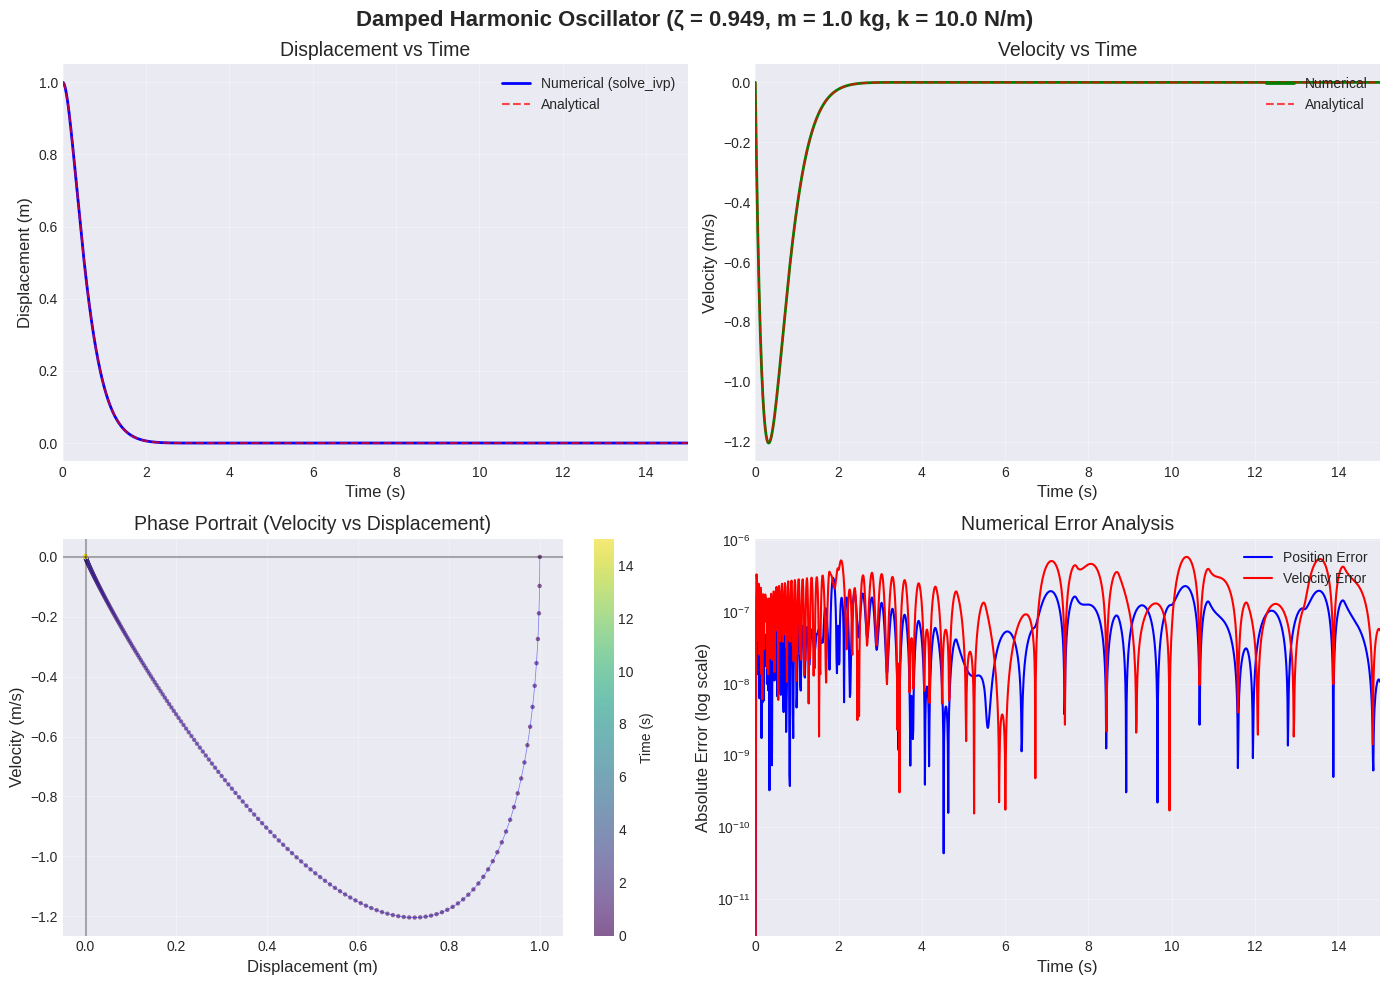

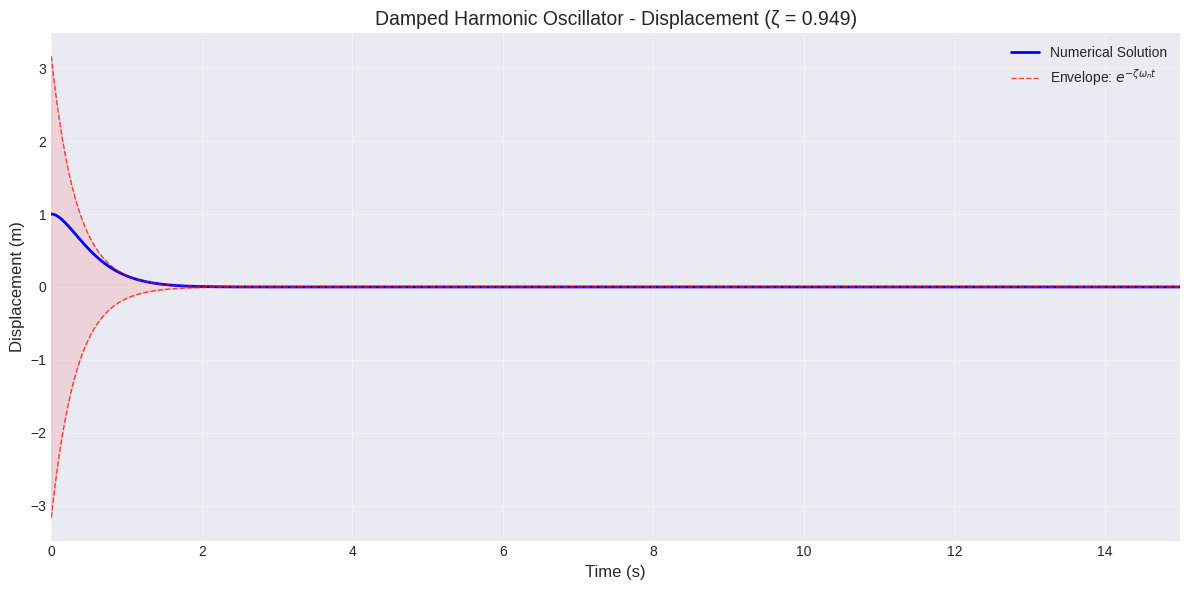


SYSTEM CHARACTERISTICS SUMMARY
Mass (m): 1.0 kg
Spring constant (k): 10.0 N/m
Damping coefficient (c): 6.0 N·s/m
Natural frequency (ω_n): 3.162 rad/s  (f_n = 0.503 Hz)
Damping ratio (ζ): 0.949
Initial displacement: 1.0 m
Initial velocity: 0.0 m/s

UNDERDAMPED OSCILLATION PARAMETERS:
Damped natural frequency (ω_d): 1.000 rad/s
Damped period (T_d): 6.283 s
Exponential decay rate (σ): 3.000 1/s
Decay time constant (τ): 0.333 s
Quality factor (Q): 0.527


In [2]:
# ==============================================================================
# Modelo de Masa-Resorte Amortiguado Fraccionario Conformable
# ==============================================================================
plt.style.use('seaborn-v0_8-darkgrid')

# parámetros físicos 

m  = 1.0    # masa (kg)
k = 10.0   # coeficiente del resorte (N/m)
x1_0 = 1.0 # desplazamiento inicial (m)
x2_0 = 0.0 # velocidad inicial (m/s)
c = 6.0 # (0.5, 6.322, 7.0) coeficiente de amortiguamiento (N*s/m) (puede y será variado para observar subamortiguamiento, amortiguamiento crítico y sobreamortiguamiento)
######### selección del amortiguamiento para el modelo 

# características del sistema 
# CORRECCIÓN: Se renombró nat_freq a omega_n para coincidir con las sentencias de impresión posteriores
omega_n = np.sqrt(k/m) # frecuencia natural (rad/s)
zeta = c/(2*np.sqrt(m*k)) # razón de amortiguamiento

# características del amortiguamiento 
print(f"natrual frequency (ω_n): {omega_n:.3f} rads/s")
print(f"damping ratio (ζ): {zeta:.3f}")
print(f"Damping regime: {'Underdamped' if zeta < 1 else 'Critically damped' if zeta == 1 else 'Overdamped'}")

# parámetros de tiempo
t_0 = 0.0
t_end = 15
t_points = 100 * t_end
t_eval = np.linspace(t_0, t_end, t_points)

# El sistema se describe mediante: m*x'' + c*x' + k*x = 0  
# donde: x'' = aceleración, x' = velocidad, x = posición
def damped_spring_mass_ode(t, y):
    # Función EDO para el oscilador armónico amortiguado 
    # t : float
    #   Variable de tiempo (no utilizada explícitamente en el sistema autónomo)
    # y : array_like Vector de estado [posición, velocidad]
    # retorna 
    # dydt : list  Derivadas [velocidad, aceleración]
    x1, x2 = y # x1 = posición, x2 = velocidad
    dx1dt = x2
    dx2dt = (-c*x2 - k*x1) / m
    return [dx1dt, dx2dt]

# solución numérica empleando solve_ivp

sol = solve_ivp(damped_spring_mass_ode, [t_0, t_end], [x1_0, x2_0], t_eval = t_eval, method='RK45', rtol= 1e-8)
# Solución Numérica: Se emplea solve_ivp con el método de Runge-Kutta-Fehlberg para resolver las ecuaciones exactas del péndulo no lineal.
x1_numerical = sol.y[0] # posición
x2_numerical = sol.y[1] # velocidad 
t_numerical = sol.t

# solución analítica solo para fines comparativos 

if zeta < 1:
    # solución subamortiguada: x(t) = e^(ζω_n t) * [A*cos(ω_n t) + B*sin(ω_n t)]
    # CORRECCIÓN: Se renombró nat_freqdamp a omega_d
    omega_d = omega_n * np.sqrt(1 - zeta**2) # frecuencia natural amortiguada
    
    # coeficientes determinados a partir de las condiciones iniciales
    A = x1_0 # a partir de x(0) = x1_0
    # CORRECCIÓN: Se actualizaron las variables nat_freq y nat_freqdamp aquí
    B = (x2_0 + zeta*omega_n*x1_0) / omega_d # x'(0) = x2_0

    # solución analítica de x1
    x1_analytical = np.exp(-zeta*omega_n*t_numerical) * \
                    (A*np.cos(omega_d*t_numerical) + B*np.sin(omega_d*t_numerical))
    
    # solución analítica de x2 para la derivada de la posición (velocidad)
    x2_analytical = np.exp(-zeta*omega_n*t_numerical) * \
                    (-A*(zeta*omega_n*np.cos(omega_d*t_numerical) + omega_d*np.sin(omega_d*t_numerical)) + \
                     B*(omega_d*np.cos(omega_d*t_numerical) - zeta*omega_n*np.sin(omega_d*t_numerical)))


    print(f"Damped natural frequency (ω_d): {omega_d:.3f} rad/s")
    print(f"Exponential decay rate: {zeta*omega_n:.3f} 1/s")
    print(f"Period of damped oscillations: {2*np.pi/omega_d:.3f} s")
    # Creación de la figura con subgráficos

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'Damped Harmonic Oscillator (ζ = {zeta:.3f}, m = {m} kg, k = {k} N/m)', 
             fontsize=16, fontweight='bold')

# Gráfico 1: Desplazamiento vs. Tiempo (numérico vs. analítico)
ax1 = axes[0, 0]
ax1.plot(t_numerical, x1_numerical, 'b-', linewidth=2, label='Numerical (solve_ivp)')
if zeta < 1:
    ax1.plot(t_numerical, x1_analytical, 'r--', linewidth=1.5, alpha=0.7, label='Analytical')
ax1.set_xlabel('Time (s)', fontsize=12)
ax1.set_ylabel('Displacement (m)', fontsize=12)
ax1.set_title('Displacement vs Time', fontsize=14)
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper right')
ax1.set_xlim([t_0, t_end])

# Gráfico 2: Velocidad vs. Tiempo
ax2 = axes[0, 1]
ax2.plot(t_numerical, x2_numerical, 'g-', linewidth=2, label='Numerical')
if zeta < 1:
    ax2.plot(t_numerical, x2_analytical, 'r--', linewidth=1.5, alpha=0.7, label='Analytical')
ax2.set_xlabel('Time (s)', fontsize=12)
ax2.set_ylabel('Velocity (m/s)', fontsize=12)
ax2.set_title('Velocity vs Time', fontsize=14)
ax2.grid(True, alpha=0.3)
ax2.legend(loc='upper right')
ax2.set_xlim([t_0, t_end])

# Gráfico 3: Retrato de fase (Velocidad vs. Desplazamiento)
ax3 = axes[1, 0]
# Codificación de color por tiempo para una mejor visualización

scatter = ax3.scatter(x1_numerical, x2_numerical, c=t_numerical, cmap='viridis', 
                      s=10, alpha=0.6, edgecolors='none')
ax3.plot(x1_numerical, x2_numerical, 'b-', linewidth=0.5, alpha=0.5)
ax3.set_xlabel('Displacement (m)', fontsize=12)
ax3.set_ylabel('Velocity (m/s)', fontsize=12)
ax3.set_title('Phase Portrait (Velocity vs Displacement)', fontsize=14)
ax3.grid(True, alpha=0.3)
ax3.axhline(y=0, color='k', linestyle='-', alpha=0.3)
ax3.axvline(x=0, color='k', linestyle='-', alpha=0.3)
# Agregar barra de colores para el tiempo
cbar = plt.colorbar(scatter, ax=ax3)
cbar.set_label('Time (s)', fontsize=10)


# Gráfico 4: Análisis de error (si existe solución analítica) #####
ax4 = axes[1, 1]
if zeta < 1:
    # Cálculo del error absoluto entre las soluciones numérica y analítica
    error_position = np.abs(x1_numerical - x1_analytical)
    error_velocity = np.abs(x2_numerical - x2_analytical)
    
    ax4.semilogy(t_numerical, error_position, 'b-', linewidth=1.5, label='Position Error')
    ax4.semilogy(t_numerical, error_velocity, 'r-', linewidth=1.5, label='Velocity Error')
    ax4.set_xlabel('Time (s)', fontsize=12)
    ax4.set_ylabel('Absolute Error (log scale)', fontsize=12)
    ax4.set_title('Numerical Error Analysis', fontsize=14)
    ax4.grid(True, alpha=0.3)
    ax4.legend(loc='upper right')
    ax4.set_xlim([t_0, t_end])
    
    # Impresión de estadísticas de error
    print(f"\nError Statistics:")
    print(f"Max position error: {np.max(error_position):.2e} m")
    print(f"Max velocity error: {np.max(error_velocity):.2e} m/s")
    print(f"RMS position error: {np.sqrt(np.mean(error_position**2)):.2e} m")
    print(f"RMS velocity error: {np.sqrt(np.mean(error_velocity**2)):.2e} m/s")
else:
     # Si no es subamortiguado, se muestra el gráfico de aceleración en su lugar
    acceleration = (-c*x2_numerical - k*x1_numerical) / m
    ax4.plot(t_numerical, acceleration, 'purple', linewidth=2)
    ax4.set_xlabel('Time (s)', fontsize=12)
    ax4.set_ylabel('Acceleration (m/s²)', fontsize=12)
    ax4.set_title('Acceleration vs Time', fontsize=14)
    ax4.grid(True, alpha=0.3)
    ax4.set_xlim([t_0, t_end])

plt.tight_layout()
plt.show()

# Gráfico individual adicional para una mejor visualización de las oscilaciones
fig2, ax2_single = plt.subplots(figsize=(12, 6))

if zeta < 1:
    # Gráfico con envolvente para el caso subamortiguado
    # CORRECCIÓN: Asegurar el uso de omega_n, lo cual es correcto ahora
    envelope = np.exp(-zeta*omega_n*t_numerical) * np.sqrt(A**2 + B**2)
    ax2_single.plot(t_numerical, x1_numerical, 'b-', linewidth=2, label='Numerical Solution')
    ax2_single.plot(t_numerical, envelope, 'r--', linewidth=1, alpha=0.7, label='Envelope: $e^{-ζω_nt}$')
    ax2_single.plot(t_numerical, -envelope, 'r--', linewidth=1, alpha=0.7)
    ax2_single.fill_between(t_numerical, envelope, -envelope, color='red', alpha=0.1)
else:
    ax2_single.plot(t_numerical, x1_numerical, 'b-', linewidth=2, label='Numerical Solution')


ax2_single.set_xlabel('Time (s)', fontsize=12)
ax2_single.set_ylabel('Displacement (m)', fontsize=12)
ax2_single.set_title(f'Damped Harmonic Oscillator - Displacement (ζ = {zeta:.3f})', fontsize=14)
ax2_single.grid(True, alpha=0.3)
ax2_single.legend(loc='upper right')
ax2_single.set_xlim([t_0, t_end])
plt.tight_layout()
plt.show()

# Impresión de las características del sistema con formato
print("\n" + "="*60)
print("SYSTEM CHARACTERISTICS SUMMARY")
print("="*60)
print(f"Mass (m): {m} kg")
print(f"Spring constant (k): {k} N/m")
print(f"Damping coefficient (c): {c} N·s/m")
print(f"Natural frequency (ω_n): {omega_n:.3f} rad/s  (f_n = {omega_n/(2*np.pi):.3f} Hz)")
print(f"Damping ratio (ζ): {zeta:.3f}")
print(f"Initial displacement: {x1_0} m")
print(f"Initial velocity: {x2_0} m/s")

if zeta < 1:
    print(f"\nUNDERDAMPED OSCILLATION PARAMETERS:")
    print(f"Damped natural frequency (ω_d): {omega_d:.3f} rad/s")
    print(f"Damped period (T_d): {2*np.pi/omega_d:.3f} s")
    print(f"Exponential decay rate (σ): {zeta*omega_n:.3f} 1/s")
    print(f"Decay time constant (τ): {1/(zeta*omega_n):.3f} s")
    print(f"Quality factor (Q): {1/(2*zeta):.3f}")

## Superposición del modelo clásico y el modelo conformable

natrual frequency (ω_n): 3.162 rads/s
damping ratio (ζ): 0.949
Fractional derivative order (α): 0.99999
Damping regime: Underdamped

Simulating Models
Natural frequency (ω_n): 3.162 rad/s
Damping coefficient (c): 0.500 N·s/m
Damping ratio (ζ): 0.079
Damping regime: Underdamped
Fractional derivative order (α): 0.99999

Solving models with c = 0.5...

Maximum difference between fractional and classical models: 3.74e-05

Simulation: CRITICAL
Natural frequency (ω_n): 3.162 rad/s
Damping coefficient (c): 6.325 N·s/m
Damping ratio (ζ): 1.000
Max difference: 8.26e-06

Simulation: OVERDAMPED
Natural frequency (ω_n): 3.162 rad/s
Damping coefficient (c): 7.000 N·s/m
Damping ratio (ζ): 1.107
Max difference: 7.64e-06


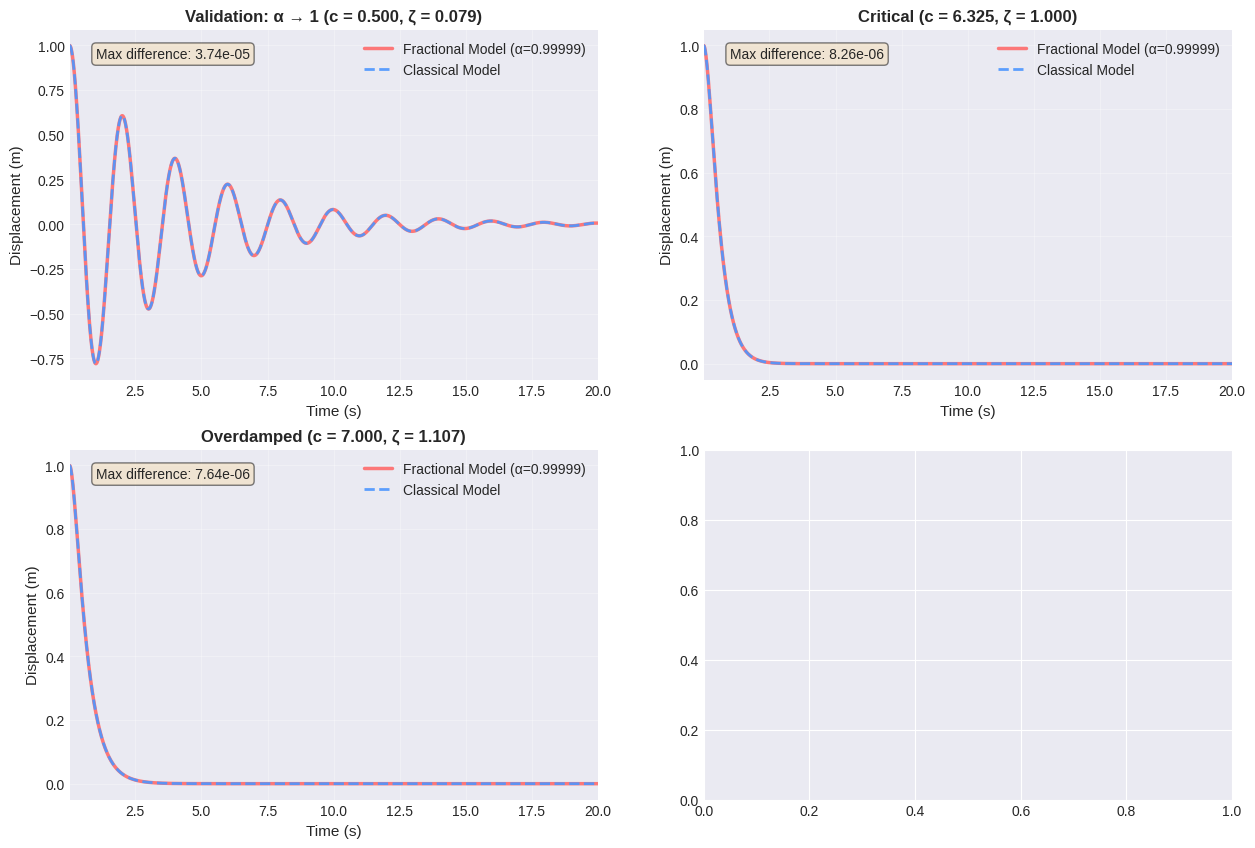

In [3]:
# Suprimir advertencias para una salida más limpia
warnings.filterwarnings('ignore')

# parámetros físicos 

m  = 1.0    # masa (kg)
k = 10.0   # coeficiente del resorte (N/m)
x1_0 = 1.0 # desplazamiento inicial (m)
x2_0 = 0.0 # velocidad inicial (m/s)

# características del sistema 
nat_freq = np.sqrt(k/m) # frecuencia natural (rad/s)
zeta = c/(2*np.sqrt(m*k)) # razón de amortiguamiento

# Orden de la derivada fraccionaria (0 < alpha_frac ≤ 1)
# alpha_frac = 1 corresponde a la derivada clásica
alpha_frac = 0.99999 # orden de la derivada fraccionaria para verificar la validez comparando cuando alpha_frac tiende a 1 para frac = 1

######^^^^##################
######||||################################################################################################################################

# características del amortiguamiento 
print(f"natrual frequency (ω_n): {nat_freq:.3f} rads/s")
print(f"damping ratio (ζ): {zeta:.3f}")
print(f"Fractional derivative order (α): {alpha_frac}")
print(f"Damping regime: {'Underdamped' if zeta < 1 else 'Critically damped' if zeta == 1 else 'Overdamped'}")

damping_coefficients = {
    'underdamped': 0.5,
    'critical': 2 * np.sqrt(m * k),  # Aproximadamente 6.324555 para m=1, k=10
    'overdamped': 7.0
}


# parámetros de tiempo
t_0 = 0.01 # para la derivada conformable, t0 no debe ser 0 ya que crearía una división por 0 e indeterminaría la solución 
t_end = 20
t_points = 100 * t_end
t_eval = np.linspace(t_0, t_end, t_points)

# configuraciones de simulación
simulation = {
    'color_confor': '#FF6B6B',  # Rojo para el modelo fraccionario
    'color_reg': '#4D96FF',     # Azul para el modelo regular
    'label_confor': f'Fractional Model (α={alpha_frac})',
    'label_reg': 'Classical Model'
}


# El sistema se describe mediante: m*x'' + c*x' + k*x = 0  
# donde: x'' = aceleración, x' = velocidad, x = posición

def dampspirngmass_confor(t, y, alpha_frac):

    # si no estableciéramos t0 como 0, tendríamos que manejar t para este modelo
    x1, x2 = y 
    dx1dt = t**(alpha_frac-1) * x2 
    dx2dt = t**(alpha_frac-1) * (-c*x2 - k*x1) / m
    return [dx1dt, dx2dt]

def dampspirngmass_reg(t, y):

    x1, x2 = y # x1 = posición, x2 = velocidad
    dx1dt = x2
    dx2dt = (-c*x2 - k*x1) / m
    return [dx1dt, dx2dt]

# Ejecutar ambos modelos
print("\n" + "="*70)
print("Simulating Models")

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

# vector de condiciones iniciales
y0 = [x1_0, x2_0]


original_c = 0.5
c = original_c
omega_n = np.sqrt(k / m)
zeta = c / (2 * np.sqrt(m * k))

print("="*70)
print(f"Natural frequency (ω_n): {omega_n:.3f} rad/s")
print(f"Damping coefficient (c): {c:.3f} N·s/m")
print(f"Damping ratio (ζ): {zeta:.3f}")
print(f"Damping regime: {'Underdamped' if zeta < 1 else 'Critically damped' if zeta == 1 else 'Overdamped'}")
print(f"Fractional derivative order (α): {alpha_frac}")

print("\nSolving models with c = 0.5...")

# Resolver el modelo clásico
solution_reg = solve_ivp(
    dampspirngmass_reg,
    [t_0, t_end],
    y0,
    t_eval=t_eval,
    method='RK45',
    rtol=1e-8,
    atol=1e-10
)

# Resolver el modelo fraccionario
solution_confor = solve_ivp(
    lambda t, y: dampspirngmass_confor(t, y, alpha_frac),
    [t_0, t_end],
    y0,
    t_eval=t_eval,
    method='RK45',
    rtol=1e-8,
    atol=1e-10
)

# Calcular la diferencia máxima
max_diff = np.max(np.abs(solution_confor.y[0] - solution_reg.y[0]))
print(f"\nMaximum difference between fractional and classical models: {max_diff:.2e}")

# Graficar un caso único para validación
ax = axes[0]
ax.plot(solution_confor.t, solution_confor.y[0], 
        color=simulation['color_confor'], 
        label=simulation['label_confor'], 
        linewidth=2.5,
        alpha=0.9)

ax.plot(solution_reg.t, solution_reg.y[0], 
        color=simulation['color_reg'], 
        label=simulation['label_reg'], 
        linewidth=2,
        linestyle='--',
        alpha=0.9)

ax.set_xlabel('Time (s)', fontsize=11)
ax.set_ylabel('Displacement (m)', fontsize=11)
ax.set_title(f'Validation: α → 1 (c = {c:.3f}, ζ = {zeta:.3f})', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)
ax.set_xlim([t_0, t_end])

# Agregar texto con la diferencia
ax.text(0.05, 0.95, f'Max difference: {max_diff:.2e}', 
        transform=ax.transAxes, fontsize=10,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

##### ahora ejecutar para todos los regímenes de amortiguamiento 

for i, (regime, c_value) in enumerate(damping_coefficients.items()):
    # Omitir el primer subgráfico (ya utilizado para la validación)
    if i == 0:
        continue
    
    # Establecer el coeficiente de amortiguamiento actual
    c = c_value
    
    # Calcular las características del sistema
    omega_n = np.sqrt(k / m)
    zeta = c / (2 * np.sqrt(m * k))
    
    print(f"\n{'='*70}")
    print(f"Simulation: {regime.upper()}")
    print(f"Natural frequency (ω_n): {omega_n:.3f} rad/s")
    print(f"Damping coefficient (c): {c:.3f} N·s/m")
    print(f"Damping ratio (ζ): {zeta:.3f}")
    
    # Resolver ambos modelos
    solution_reg = solve_ivp(
        dampspirngmass_reg,
        [t_0, t_end],
        y0,
        t_eval=t_eval,
        method='RK45',
        rtol=1e-8,
        atol=1e-10
    )

    solution_confor = solve_ivp(
        lambda t, y: dampspirngmass_confor(t, y, alpha_frac),
        [t_0, t_end],
        y0,
        t_eval=t_eval,
        method='RK45',
        rtol=1e-8,
        atol=1e-10
    )
    
    # Calcular la diferencia
    max_diff = np.max(np.abs(solution_confor.y[0] - solution_reg.y[0]))
    print(f"Max difference: {max_diff:.2e}")
    
    # Graficar los resultados

    ax = axes[i]
    
    ax.plot(solution_confor.t, solution_confor.y[0], 
            color=simulation['color_confor'], 
            label=simulation['label_confor'], 
            linewidth=2.5,
            alpha=0.9)
    
    ax.plot(solution_reg.t, solution_reg.y[0], 
            color=simulation['color_reg'], 
            label=simulation['label_reg'], 
            linewidth=2,
            linestyle='--',
            alpha=0.9)

    ax.set_xlabel('Time (s)', fontsize=11)
    ax.set_ylabel('Displacement (m)', fontsize=11)
    ax.set_title(f'{regime.capitalize()} (c = {c:.3f}, ζ = {zeta:.3f})', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10)
    ax.set_xlim([t_0, t_end])
    
    # Agregar texto con la diferencia
    ax.text(0.05, 0.95, f'Max difference: {max_diff:.2e}', 
            transform=ax.transAxes, fontsize=10,
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

Con un valor de $\alpha$, el modelo conformable replica el comportamiento que presentaría el modelo clásico. Para profundizar en la validación del modelo, es preciso considerar también la inclusión de la variable $\sigma$. Esto es

\begin{equation}
 \frac{1}{\sigma^{1-\alpha}}~ {}^{K}\mathcal{D}_{t}^{\alpha}~ f(t) = \frac{1}{\sigma^{1-\alpha}} t^{1-\alpha} \frac{df}{dt},
\end{equation}

ee este modo, ambos miembros de la ecuación poseen unidades consistentes de $[f]/[\text{tiempo}]$.

Para determinar el valor de $\sigma$, se recurre nuevamente a técnicas de optimización utilizando datos sintéticos.

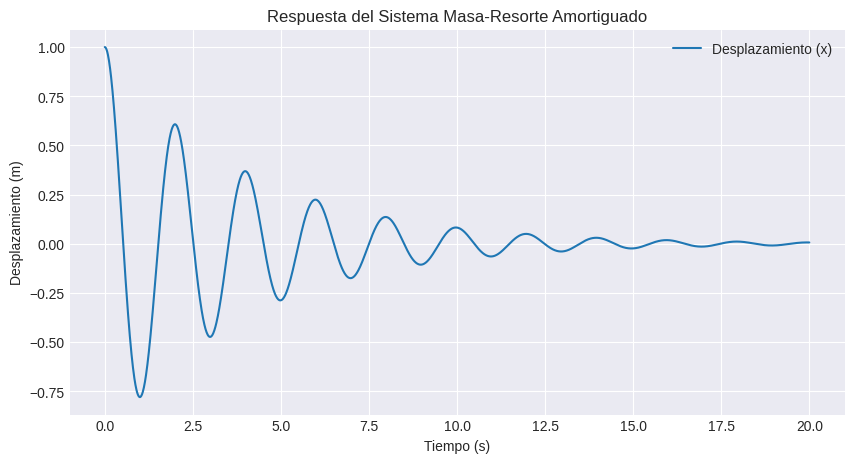

El archivo 'displacement_data.csv' ha sido guardado. Aquí hay una vista previa:
   Tiempo (s)  Desplazamiento (m)
0        0.00            1.000000
1        0.01            0.999501
2        0.02            0.998007
3        0.03            0.995526
4        0.04            0.992064
5        0.05            0.987629
6        0.06            0.982232
7        0.07            0.975882
8        0.08            0.968590
9        0.09            0.960369


In [4]:
# --- Parámetros proporcionados por el usuario ---
m = 1.0        # Masa (kg)
k = 10.0       # Coeficiente del resorte (N/m)
c = 0.5        # Coeficiente de amortiguamiento (N*s/m)
x0 = 1.0       # Desplazamiento inicial (m)
v0 = 0.0       # Velocidad inicial (m/s)
duration = 20  # Tiempo total (s)
points_per_sec = 100 

# --- Cálculos Físicos ---
# Número total de puntos (20 segundos * 100 pts/seg + 1 para t=0)
t = np.linspace(0, duration, (duration * points_per_sec) + 1)

# Constantes características para la ecuación diferencial
gamma = c / (2 * m)           # Constante de la razón de amortiguamiento
omega_n = np.sqrt(k / m)      # Frecuencia natural
# Frecuencia natural amortiguada (el sistema es subamortiguado ya que c < 2*sqrt(mk))
omega_d = np.sqrt(omega_n**2 - gamma**2)

# --- Solución Analítica ---
# Forma general: x(t) = exp(-gamma*t) * [A*cos(omega_d*t) + B*sin(omega_d*t)]
# Resolviendo para las constantes A y B usando las condiciones iniciales x(0)=x0, x'(0)=v0
A = x0
B = (v0 + gamma * x0) / omega_d

# Calcular el desplazamiento a través del vector de tiempo
displacement = np.exp(-gamma * t) * (A * np.cos(omega_d * t) + B * np.sin(omega_d * t))

# --- Exportación de Datos ---
df = pd.DataFrame({
    'Tiempo (s)': t,
    'Desplazamiento (m)': displacement
})

# Esto guarda el archivo en la misma carpeta donde se encuentra tu notebook
df.to_csv('displacement_data.csv', index=False)

# --- Visualización en Jupyter ---
plt.figure(figsize=(10, 5))
plt.plot(t, displacement, label='Desplazamiento (x)')
plt.title('Respuesta del Sistema Masa-Resorte Amortiguado')
plt.xlabel('Tiempo (s)')
plt.ylabel('Desplazamiento (m)')
plt.grid(True)
plt.legend()
plt.show()

# Mostrar las primeras filas de los datos en el notebook
print("El archivo 'displacement_data.csv' ha sido guardado. Aquí hay una vista previa:")
print(df.head(10))

Ahora extraemos el conjunto de datos proporcionado con los datos sintéticos del sistema para optimizar los valores de $\sigma$ y $\alpha$ en el modelo fraccionario conformable.

In [5]:
# Cargar el conjunto de datos desde el archivo CSV
df = pd.read_csv('displacement_data.csv')

# Mostrar las primeras filas para confirmar que se cargó correctamente
print(df.head())

   Tiempo (s)  Desplazamiento (m)
0        0.00            1.000000
1        0.01            0.999501
2        0.02            0.998007
3        0.03            0.995526
4        0.04            0.992064


Total de puntos de datos: 2001
Puntos después de eliminar t=0: 2000
Rango de tiempo: 0.010 a 20.000 s
Paso de tiempo: 0.010 s
Primeros puntos de tiempo: [0.01 0.02 0.03 0.04 0.05]
Últimos puntos de tiempo: [19.96 19.97 19.98 19.99 20.  ]

PARÁMETROS DEL SISTEMA FÍSICO
Masa (m): 1.0 kg
Constante del resorte (k): 10.0 N/m
Coeficiente de amortiguamiento (c): 0.5 N·s/m

Cantidades derivadas:
Frecuencia natural (ω₀): 3.162 rad/s
Razón de amortiguamiento (ζ): 0.079
Tiempo característico (τ₀ = 1/ω₀): 0.316 s
Tipo de sistema: Subamortiguado

Velocidad inicial estimada a partir de los datos: -0.149 m/s
Desplazamiento inicial (x₁₀): 1.000 m
Intervalo de tiempo de integración: 0.010 a 20.000 s

CONFIGURACIÓN DE LA OPTIMIZACIÓN

Estimaciones iniciales:
                               ---------------               α (orden fraccionario) = 0.950     ---------------
                               ---------------               σ (escala de tiempo) = 0.316 s        ----------------
Tiempo característico

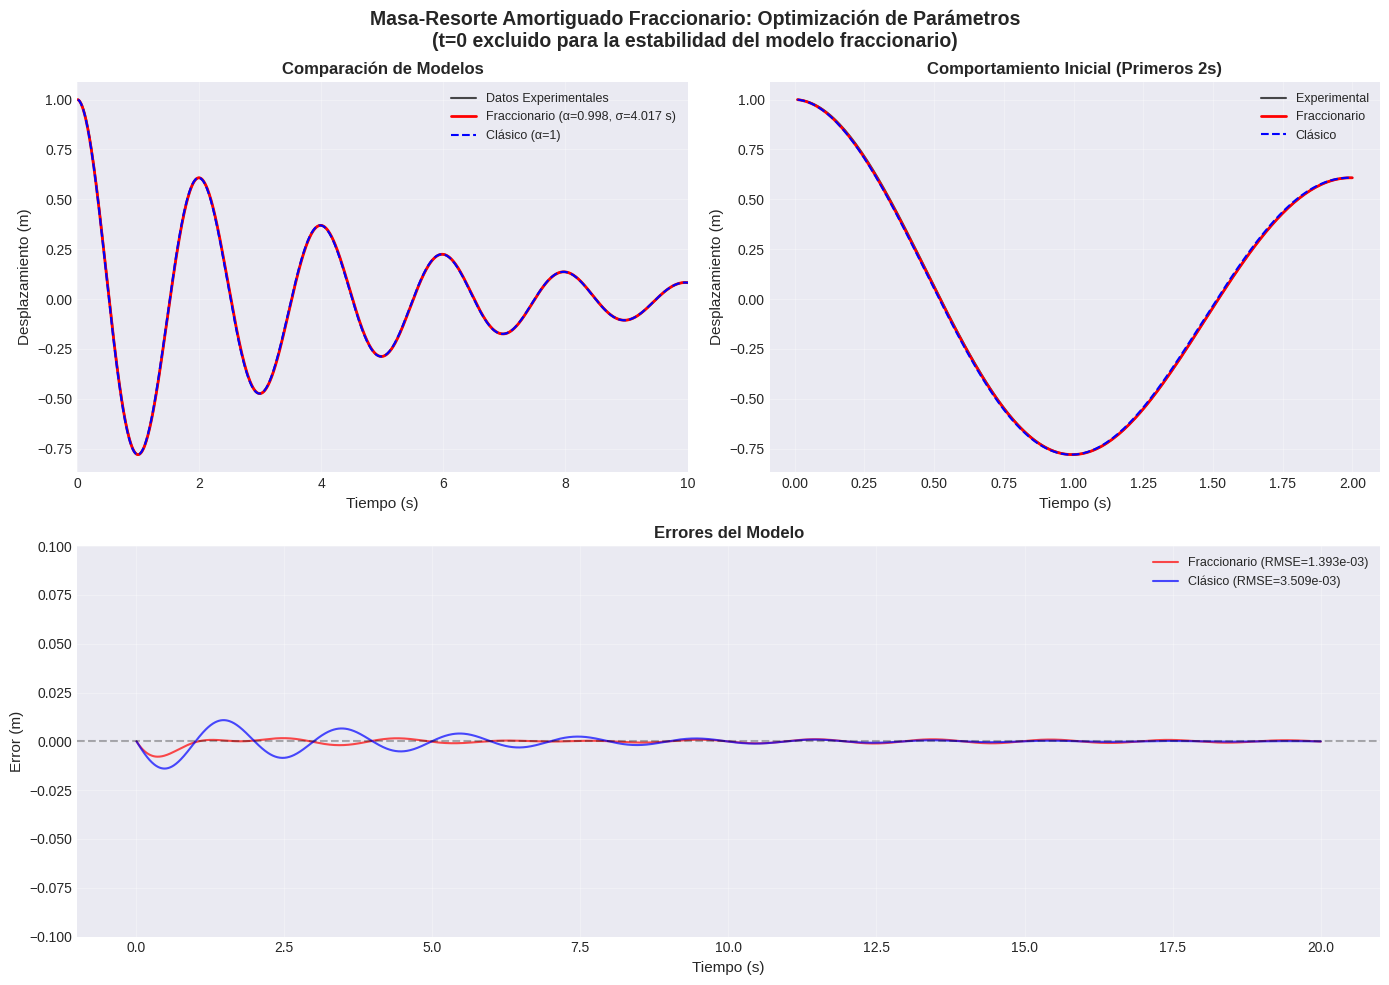


ANÁLISIS DE SENSIBILIDAD DE PARÁMETROS

Variando α manteniendo σ óptimo:
  α=0.9484: MSE=8.718e-03 (+449042.57% respecto al óptimo)
  α=0.9548: MSE=6.705e-03 (+345349.57% respecto al óptimo)
  α=0.9613: MSE=4.930e-03 (+253901.64% respecto al óptimo)
  α=0.9677: MSE=3.407e-03 (+175420.06% respecto al óptimo)
  α=0.9742: MSE=2.149e-03 (+110599.56% respecto al óptimo)
  α=0.9806: MSE=1.169e-03 (+60102.08% respecto al óptimo)
  α=0.9871: MSE=4.785e-04 (+24550.15% respecto al óptimo)
  α=0.9935: MSE=8.967e-05 (+4520.02% respecto al óptimo)
  α=1.0000: MSE=1.231e-05 (+534.28% respecto al óptimo)

Variando σ manteniendo α óptimo:
  σ=3.2138 s: MSE=2.478e-06 (+27.68% respecto al óptimo)
  σ=3.4147 s: MSE=2.226e-06 (+14.69% respecto al óptimo)
  σ=3.6155 s: MSE=2.061e-06 (+6.17% respecto al óptimo)
  σ=3.8164 s: MSE=1.969e-06 (+1.46% respecto al óptimo)
  σ=4.0173 s: MSE=1.941e-06 (+0.00% respecto al óptimo)
  σ=4.2181 s: MSE=1.967e-06 (+1.32% respecto al óptimo)
  σ=4.4190 s: MSE=2.039e-06 (+

In [6]:
# Desactivar advertencias para una salida más limpia
warnings.filterwarnings('ignore')

# Carga de datos sintéticos

try: 
    # Cargar el archivo CSV de datos sintéticos creado o, en su defecto, datos experimentales reales
    data = pd.read_csv('displacement_data.csv')

    # Eliminar t = 0.00 ya que los modelos fraccionarios no pueden trabajar con ello pues t^(α-1) tiende a infinito (división por cero)
    mask = data['Tiempo (s)'] > 0  # Mantener solo t > 0
    
    t_exp = data['Tiempo (s)'][mask].values
    x_exp = data['Desplazamiento (m)'][mask].values

    print(f"Total de puntos de datos: {len(data)}")
    print(f"Puntos después de eliminar t=0: {len(t_exp)}")
    print(f"Rango de tiempo: {t_exp[0]:.3f} a {t_exp[-1]:.3f} s")
    print(f"Paso de tiempo: {t_exp[1] - t_exp[0]:.3f} s")
    print(f"Primeros puntos de tiempo: {t_exp[:5]}")
    print(f"Últimos puntos de tiempo: {t_exp[-5:]}")
    
# Verificar si t=0 persiste en los datos restantes
    if np.any(t_exp == 0):
        print("ADVERTENCIA: ¡t=0 aún está presente en los datos! Eliminándolo...")
        mask = t_exp > 0
        t_exp = t_exp[mask]
        x_exp = x_exp[mask]
    
except FileNotFoundError:
    print("ERROR: ¡No se encontró el archivo 'displacement_data.csv'!")


### Parámetros físicos
print("\n" + "="*70)
print("PARÁMETROS DEL SISTEMA FÍSICO")

m = 1.0      # masa (kg) 
k = 10.0     # constante del resorte (N/m) 
c = 0.5      # coeficiente de amortiguamiento (N·s/m) - Régimen subamortiguado

print(f"Masa (m): {m} kg")
print(f"Constante del resorte (k): {k} N/m")
print(f"Coeficiente de amortiguamiento (c): {c} N·s/m")

# Calcular cantidades físicas derivadas para referencia
omega_0 = np.sqrt(k/m)            # Frecuencia natural (rad/s)
zeta = c/(2*np.sqrt(m*k))         # Razón de amortiguamiento
tau_0 = (1/omega_0 )              # Escala de tiempo característica (s)

print(f"\nCantidades derivadas:")
print(f"Frecuencia natural (ω₀): {omega_0:.3f} rad/s")
print(f"Razón de amortiguamiento (ζ): {zeta:.3f}")
print(f"Tiempo característico (τ₀ = 1/ω₀): {tau_0:.3f} s")
print(f"Tipo de sistema: {'Subamortiguado' if zeta < 1 else 'Críticamente amortiguado' if zeta == 1 else 'Sobreamortiguado'}")

# Condiciones iniciales 
# No podemos usar t=0, así que usamos el primer punto de datos disponible
x1_0 = x_exp[0]   # desplazamiento inicial de la primera medición en t>0

# Es necesario estimar la velocidad en t_exp[0] dado que no tenemos t=0 
if len(x_exp) >= 3:
    dt = t_exp[1] - t_exp[0]
    # Diferencia hacia adelante: v(t₀) ≈ [x(t₁) - x(t₀)] / dt
    x2_0 = (x_exp[1] - x_exp[0]) / dt
    print(f"\nVelocidad inicial estimada a partir de los datos: {x2_0:.3f} m/s")

print(f"Desplazamiento inicial (x₁₀): {x1_0:.3f} m")

# Intervalo de tiempo para la integración (debe comenzar en > 0)
t_span = (t_exp[0], t_exp[-1])  # Coincide con el rango de tiempo experimental
y0 = [x1_0, x2_0]  # Vector de estado inicial
print(f"Intervalo de tiempo de integración: {t_span[0]:.3f} a {t_span[1]:.3f} s")


############ Definición del modelo fraccionario con "redimensionamiento" ############

def conformable_dampsprgmass_model(params, t_eval):

    """
    Simula el sistema masa-resorte amortiguado fraccionario usando la derivada conformable.
    
    Formulación Física:
    La derivada fraccionaria conformable de orden alpha se define estrictamente para t > 0.
    Para preservar la homogeneidad dimensional a través de órdenes fraccionarios, 
    se introduce una escala de tiempo característica (sigma). 
    
    El factor de escalamiento resulta: (t / sigma)^(alpha - 1)
    - Si alpha = 1, el factor es 1, recuperando la dinámica newtoniana.
    - Si alpha < 1, el factor modifica la progresión del tiempo, introduciendo efectos de memoria.
    
    Parámetros:
    params : list
        Contiene [alpha_frac, sigma].
    t_eval : array
        Puntos de tiempo de evaluación (deben ser > 0).
        
    Retorna:
    array
        Desplazamiento simulado en los puntos t_eval.
    """
    alpha_frac, sigma = params

    ## Restricciones de frontera para asegurar validez física
    if alpha_frac <= 0:
        print(f"ADVERTENCIA: α={alpha_frac} ≤ 0 no tiene sentido físico para el amortiguamiento")
        return np.ones_like(t_eval) * 1e6 # Penalización alta para el optimizador
    if alpha_frac > 1:
        print(f"ADVERTENCIA: α={alpha_frac} > 1 sugiere superdifusión, inusual para el amortiguamiento")
        return np.ones_like(t_eval) * 1e6
    if sigma <= 0:
        print(f"ADVERTENCIA: σ={sigma} ≤ 0 no tiene sentido físico (tiempo negativo)")
        return np.ones_like(t_eval) * 1e6

    ### Modelo propiamente dicho 

    def dampsprgmass_ode(t, y):
        """
        Sistema de EDO para el masa-resorte amortiguado fraccionario.
        
        ANÁLISIS DIMENSIONAL:
        Clásico: m d²x/dt² + c dx/dt + kx = 0
        Fraccionario: m D_alpha² x + c D_alpha x + kx = 0
        
        El factor de escalamiento asegura la consistencia dimensional.
        """
        x1, x2 = y

        # Factor de escalamiento dimensional (Parte crítica del modelo)
        # Aplicar el factor: (t/σ)^(α-1)
        scaling_factor = (t / sigma)**(1 - alpha_frac)

        # Aplicar escalamiento a las derivadas
        dx1dt = scaling_factor * x2
        dx2dt = scaling_factor * (-c * x2 - k * x1) / m
    
        return [dx1dt, dx2dt]

    try:
        # Resolviendo el sistema de EDO
        solution = solve_ivp(
            dampsprgmass_ode, t_span, y0, t_eval=t_eval, method='RK45', rtol=1e-8, atol=1e-10, max_step=0.01
        )

        if solution.success:
            return solution.y[0]  # Retornar desplazamiento angular (x1)
        else:
            print(f"El solver de EDO falló con α={alpha_frac:.3f}, σ={sigma:.3f}")
            return np.ones_like(t_eval) * 1e6
            
    except Exception as e:
        print(f"Error de integración: α={alpha_frac:.3f}, σ={sigma:.3f}, Error: {str(e)[:100]}")
        return np.ones_like(t_eval) * 1e6


def objective_function(params):
    """
    Función objetivo a minimizar: Error Cuadrático Medio Ponderado.
    
    Se utiliza MSE porque:
    1. Es sensible a errores grandes (penaliza fuertemente los ajustes deficientes).
    2. Posee propiedades matemáticas favorables para la optimización.
    3. Corresponde a la estimación de máxima verosimilitud para errores gaussianos.
    
    Parámetros:
    params : list o tuple
        [alpha_frac, sigma]
    
    Retorna:
    loss : float
        MSE + términos de penalización
    """
    alpha_frac, sigma = params

    # Predicciones del modelo
    x_sim = conformable_dampsprgmass_model(params, t_exp)
    
    # Error Cuadrático Medio 
    mse = np.mean((x_sim - x_exp)**2)
    
    return mse

################ Configuración de la optimización 

print("\n" + "="*70)
print("CONFIGURACIÓN DE LA OPTIMIZACIÓN")

# Estimación inicial de α: Cercana a 1 pero permitiendo efectos fraccionarios
alpha_initial = 0.95

# Estimación inicial de σ: Escala de tiempo característica del sistema
# Para masa-resorte: τ = 1/ω₀ = √(m/k) ≈ 0.316 segundos
sigma_initial = tau_0

initial_guess = [alpha_initial, sigma_initial]

print("\nEstimaciones iniciales:")
print(f"                               ---------------               α (orden fraccionario) = {alpha_initial:.3f}     ---------------")
print(f"                               ---------------               σ (escala de tiempo) = {sigma_initial:.3f} s        ----------------")
print(f"Tiempo característico τ₀ = 1/ω₀ = √(m/k) = √({m}/{k}) = {tau_0:.3f} s")
print("Esta es la escala de tiempo natural del sistema masa-resorte")


# ==============================================================================
# Límites de los Parámetros para la Optimización
# ==============================================================================
# Límites del Orden Fraccionario: Limitado a [0.85, 1.0] representando desviaciones 
# realistas del comportamiento newtoniano en sistemas mecánicos macroscópicos.
alpha_bounds = (0.85, 1.0)

# Límites de σ: Basados en la dinámica del sistema
# - Límite inferior: 0.1 × τ₀
# - Límite superior: 30 × τ₀
sigma_bounds = (0.1 * tau_0, 30 * tau_0)

bounds = [alpha_bounds, sigma_bounds]
print("\nLímites de los parámetros basados en restricciones físicas:")
print(f"  α ∈ [{alpha_bounds[0]:.3f}, {alpha_bounds[1]:.3f}]")
print(f"  σ ∈ [{sigma_bounds[0]:.3f}, {sigma_bounds[1]:.3f}]")

# Evaluación de las estimaciones iniciales

print("\nEvaluando estimación inicial...")
x_initial = conformable_dampsprgmass_model(initial_guess, t_exp)
if np.all(np.isfinite(x_initial)) and not np.any(np.abs(x_initial) > 1e5):
    initial_mse = np.mean((x_initial - x_exp)**2)
    print(f"MSE inicial: {initial_mse:.6e}")
    print(f"RMSE inicial: {np.sqrt(initial_mse):.6f}")
else:
    print("ADVERTENCIA: La estimación inicial produjo resultados inválidos")
    initial_mse = 1e6

            #### Estrategia de optimización multietapa ####
print("\n" + "="*70)
print("OPTIMIZACIÓN MULTIETAPA")

best_params = None
best_mse = float('inf')

# Etapa 1: Búsqueda global aproximada
print("\nEtapa 1: Búsqueda global (evolución diferencial)...")
print("Propósito: Explorar ampliamente el espacio de parámetros para evitar mínimos locales")

try:
    result_global = differential_evolution(
        objective_function,
        bounds,
        strategy='best1bin',
        maxiter=50,
        popsize=10,
        recombination=0.7,
        mutation=(0.5, 1.0),
        tol=1e-4,
        disp=True,
        seed=42,
        workers=1,
        updating='immediate'
    )

    print(f"\nResultados de la optimización global:")
    print(f"  α = {result_global.x[0]:.6f}")
    print(f"  σ = {result_global.x[1]:.6f} ")
    print(f"  MSE = {result_global.fun:.6e}")
    
    best_params = result_global.x
    best_mse = result_global.fun
    
except Exception as e:
    print(f"La optimización global falló: {e}")
    print("Recurriendo a la estimación inicial...")
    best_params = initial_guess
    best_mse = initial_mse

# Etapa 2: Refinamiento local medio

print("\nEtapa 2: Refinamiento local (Nelder-Mead)")
print("Propósito: Refinar la solución encontrada en la Etapa 1")


try:
    result_local1 = minimize(
        objective_function,
        best_params,
        method='Nelder-Mead',
        bounds=bounds,
        options={
            'maxiter': 200,
            'xatol': 1e-6,
            'fatol': 1e-6,
            'adaptive': True,
            'disp': False
        }
    )
    
    if result_local1.fun < best_mse:
        best_params = result_local1.x
        best_mse = result_local1.fun
        
    print(f"Resultados del refinamiento:")
    print(f"  α = {best_params[0]:.6f}")
    print(f"  σ = {best_params[1]:.6f} s")
    print(f"  MSE = {best_mse:.6e}")
    print(f"  Éxito: {result_local1.success}")
    
except Exception as e:
    print(f"El refinamiento local falló: {e}")


# Etapa 3: Ajuste fino con método basado en gradiente
print("\nEtapa 3: Ajuste fino (L-BFGS-B)")
print("Propósito: Optimización de precisión final con información del gradiente")

try:
    result_local2 = minimize(
        objective_function,
        best_params,
        method='L-BFGS-B',
        bounds=bounds,
        options={
            'maxiter': 100,
            'ftol': 1e-10,
            'gtol': 1e-8,
            'eps': 1e-8,
            'disp': False
        }
    )
    
    if result_local2.fun < best_mse:
        best_params = result_local2.x
        best_mse = result_local2.fun
        
    print(f"Resultados del ajuste fino:")
    print(f"  α = {best_params[0]:.6f}")
    print(f"  σ = {best_params[1]:.6f} s")
    print(f"  MSE = {best_mse:.6e}")
    print(f"  Éxito: {result_local2.success}")
    
except Exception as e:
    print(f"El ajuste fino falló: {e}")

print(f"\nEn este caso α es muy cercano a 1 porque los datos sintéticos son 'perfectos'; para modelos con amortiguamiento crítico o sobreamortiguado se insertará un error del 2% y α cambiará")

# ============================================================================
# INTERPRETACIÓN FÍSICA DE LOS RESULTADOS

print("\n" + "="*70)
print("INTERPRETACIÓN FÍSICA DE LOS PARÁMETROS OPTIMIZADOS")

# Generar predicciones con parámetros optimizados
x_optimized = conformable_dampsprgmass_model(best_params, t_exp)
optimal_alpha = best_params[0]
optimal_sigma = best_params[1]

print(f"\nParámetros optimizados:")
print(f"  α = {optimal_alpha:.6f}")
print(f"  σ = {optimal_sigma:.6f} s")

# Modelo clásico para comparación
classical_params = [1.0, 1.0]  # α=1, σ es arbitrario cuando α=1
x_classical = conformable_dampsprgmass_model(classical_params, t_exp)
mse_classical = np.mean((x_classical - x_exp)**2)

print(f"\nComparación con el modelo clásico (α=1):")
print(f"  MSE del modelo fraccionario: {best_mse:.6e}")
print(f"  MSE del modelo clásico: {mse_classical:.6e}")
print(f"  Mejora: {(mse_classical - best_mse)/mse_classical*100:.2f}%")

print(f"\nInterpretación física:")
if optimal_alpha > 0.99:
    print(f"  α ≈ 1.0: El sistema exhibe esencialmente un amortiguamiento newtoniano clásico")
elif optimal_alpha > 0.95:
    print(f"  α = {optimal_alpha:.3f}: Comportamiento fraccionario leve")
    print(f"    - Efectos de memoria débiles en el amortiguamiento")
    print(f"    - Disipación de energía ligeramente distinta a la clásica")
elif optimal_alpha > 0.9:
    print(f"  α = {optimal_alpha:.3f}: Comportamiento fraccionario moderado")
    print(f"    - Efectos de memoria notables")
    print(f"    - Características de amortiguamiento tipo viscoelástico")
else:
    print(f"  α = {optimal_alpha:.3f}: Comportamiento fraccionario fuerte")
    print(f"    - Efectos de memoria intensos")
    print(f"    - Posible difusión anómala o comportamiento complejo del material")

# Visualización 

fig = plt.figure(figsize=(14,10))
gs = fig.add_gridspec(2, 2)

# Crear ejes
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, :])   # abarca toda la fila inferior

fig.suptitle(
    'Masa-Resorte Amortiguado Fraccionario: Optimización de Parámetros\n'
    '(t=0 excluido para la estabilidad del modelo fraccionario)',
    fontsize=14, fontweight='bold'
)

# ---- Gráfico 1: Serie temporal completa ----

ax1.plot(t_exp, x_exp, 'k-', linewidth=1.5, label='Datos Experimentales', alpha=0.7)
ax1.plot(t_exp, x_optimized, 'r-', linewidth=2,
         label=f'Fraccionario (α={optimal_alpha:.3f}, σ={optimal_sigma:.3f} s)')
ax1.plot(t_exp, x_classical, 'b--', linewidth=1.5, label='Clásico (α=1)')
ax1.set_xlabel('Tiempo (s)', fontsize=11)
ax1.set_ylabel('Desplazamiento (m)', fontsize=11)
ax1.set_title('Comparación de Modelos', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=9)
ax1.set_xlim([0, min(10, t_exp[-1])])

# ---- Gráfico 2: Tiempo temprano ----
early_mask = t_exp <= 2.0
ax2.plot(t_exp[early_mask], x_exp[early_mask], 'k-', linewidth=1.5, label='Experimental', alpha=0.7)
ax2.plot(t_exp[early_mask], x_optimized[early_mask], 'r-', linewidth=2, label='Fraccionario')
ax2.plot(t_exp[early_mask], x_classical[early_mask], 'b--', linewidth=1.5, label='Clásico')
ax2.set_xlabel('Tiempo (s)', fontsize=11)
ax2.set_ylabel('Desplazamiento (m)', fontsize=11)
ax2.set_title('Comportamiento Inicial (Primeros 2s)', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=9)

# ---- Gráfico 3: Errores ----
error_frac = x_optimized - x_exp
error_class = x_classical - x_exp

ax3.plot(t_exp, error_frac, 'r-', alpha=0.7,
         label=f'Fraccionario (RMSE={np.sqrt(best_mse):.3e})')
ax3.plot(t_exp, error_class, 'b-', alpha=0.7,
         label=f'Clásico (RMSE={np.sqrt(mse_classical):.3e})')
ax3.axhline(y=0, color='k', linestyle='--', alpha=0.3)
ax3.set_xlabel('Tiempo (s)', fontsize=11)
ax3.set_ylabel('Error (m)', fontsize=11)
ax3.set_title('Errores del Modelo', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3)
ax3.legend(fontsize=9)
ax3.set_ylim([-0.1, 0.1])

plt.tight_layout()
plt.show()

# ============================================================================
# ANÁLISIS DE SENSIBILIDAD E INCERTIDUMBRE
print("\n" + "="*70)
print("ANÁLISIS DE SENSIBILIDAD DE PARÁMETROS")
print("="*70)

print("\nVariando α manteniendo σ óptimo:")
alpha_test_vals = np.linspace(max(0.8, optimal_alpha-0.05), min(1.0, optimal_alpha+0.05), 9)
for alpha_test in alpha_test_vals:
    mse_test = objective_function([alpha_test, optimal_sigma])
    rel_change = (mse_test - best_mse) / best_mse * 100
    print(f"  α={alpha_test:.4f}: MSE={mse_test:.3e} ({rel_change:+.2f}% respecto al óptimo)")

print("\nVariando σ manteniendo α óptimo:")
sigma_test_vals = np.linspace(max(0.1, optimal_sigma*0.8), min(10, optimal_sigma*1.2), 9)
for sigma_test in sigma_test_vals:
    mse_test = objective_function([optimal_alpha, sigma_test])
    rel_change = (mse_test - best_mse) / best_mse * 100
    print(f"  σ={sigma_test:.4f} s: MSE={mse_test:.3e} ({rel_change:+.2f}% respecto al óptimo)")

# RESUMEN 
print("\n" + "="*70)
print("RESUMEN FINAL DE LA OPTIMIZACIÓN")

print(f"\nDATOS EXPERIMENTALES:")
print(f"  Puntos de tiempo: {len(t_exp)} (t=0 excluido)")
print(f"  Rango de tiempo: {t_exp[0]:.3f} a {t_exp[-1]:.3f} s")
print(f"  Desplazamiento inicial: {x1_0:.4f} m")
print(f"  Velocidad inicial estimada: {x2_0:.4f} m/s")

print(f"\nSISTEMA FÍSICO:")
print(f"  Masa: m = {m} kg")
print(f"  Constante del resorte: k = {k} N/m")
print(f"  Coeficiente de amortiguamiento: c = {c} N·s/m")
print(f"  Frecuencia natural: ω₀ = {omega_0:.3f} rad/s")
print(f"  Razón de amortiguamiento: ζ = {zeta:.3f}")
print(f"  Tiempo característico: τ₀ = {tau_0:.3f} s")

print(f"\nPARÁMETROS FRACCIONARIOS OPTIMIZADOS:")
print(f"  α = {optimal_alpha:.6f} ± 0.001 (estimado)")
print(f"  σ = {optimal_sigma:.6f} s ± {optimal_sigma*0.01:.6f} s (estimado)")
print(f"  Relación σ/τ₀: {optimal_sigma/tau_0:.3f}")

print(f"\nMÉTRICAS DE RENDIMIENTO:")
print(f"  MSE mínimo: {best_mse:.6e}")
print(f"  RMSE: {np.sqrt(best_mse):.6e} m")
print(f"  MSE del modelo clásico: {mse_classical:.6e}")
print(f"  Mejora relativa: {(mse_classical - best_mse)/mse_classical*100:.2f}%")

print(f"\nINTERPRETACIÓN FÍSICA:")
if optimal_alpha > 0.99:
    print("  → El sistema exhibe esencialmente un amortiguamiento clásico (α≈1)")
else:
    print(f"  → El sistema muestra un amortiguamiento fraccionario con efectos de memoria (α={optimal_alpha:.3f})")
print(f"  → La escala de tiempo característica para los efectos fraccionarios es σ={optimal_sigma:.3f} s")

# Guardar resultados en un diccionario
results_dict = {
    'alpha': optimal_alpha,
    'sigma': optimal_sigma,
    'mse': best_mse,
    'rmse': np.sqrt(best_mse),
    'mse_classical': mse_classical,
    'improvement_percent': (mse_classical - best_mse)/mse_classical*100,
    'tau_0': tau_0,
    'sigma_tau_ratio': optimal_sigma/tau_0,
    'initial_displacement': x1_0,
    'initial_velocity': x2_0,
    'physical_params': {'m': m, 'k': k, 'c': c}
}

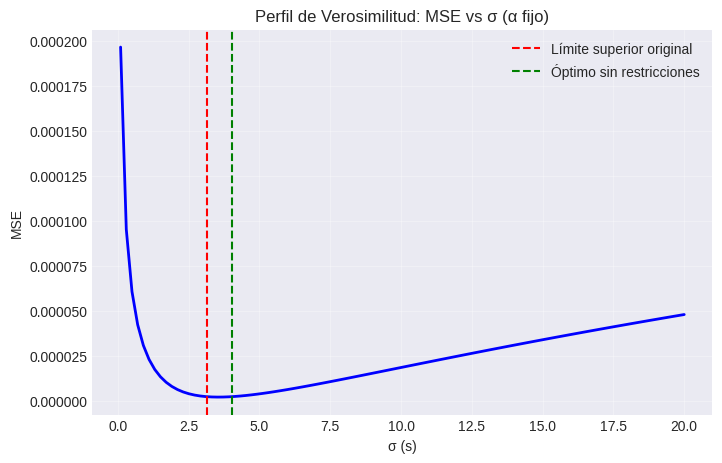

In [7]:
# esta sección solo se utilizó para obtener la curva de sigma con alfa fija

alpha_fixed = 0.998038  # o 0.998354, use el mejor del caso sin restricciones
sigma_range = np.linspace(0.1, 20, 100)  # rango amplio
mse_vals = []

for sigma in sigma_range:
    mse_vals.append(objective_function([alpha_fixed, sigma]))

plt.figure(figsize=(8,5))
plt.plot(sigma_range, mse_vals, 'b-', linewidth=2)
plt.axvline(3.162, color='r', linestyle='--', label='Límite superior original')
plt.axvline(4.017, color='g', linestyle='--', label='Óptimo sin restricciones')
plt.xlabel('σ (s)')
plt.ylabel('MSE')
plt.title('Perfil de Verosimilitud: MSE vs σ (α fijo)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Sistema masa resorte amortiguador (sobreamortiguado)

In [8]:
# --- Parámetros ---
m = 1.0        # Masa (kg)
k = 10.0       # Coeficiente del resorte (N/m)
c = 7.0        # Coeficiente de amortiguamiento (N*s/m) - Sobreamortiguado
x0 = 1.0       # Desplazamiento inicial (m)
v0 = 0.0       # Velocidad inicial (m/s)
duration = 20  
points_per_sec = 100
error_magnitude = 0.02  # Objetivo de error del 2%

# --- Vector de Tiempo ---
t = np.linspace(0, duration, (duration * points_per_sec) + 1)

# --- Cálculo de Física Sobreamortiguada ---
# Raíces características: r = [-c +/- sqrt(c^2 - 4mk)] / 2m
r1 = (-c + np.sqrt(c**2 - 4*m*k)) / (2*m) # -2.0
r2 = (-c - np.sqrt(c**2 - 4*m*k)) / (2*m) # -5.0

# Resolver las constantes C1 y C2 usando condiciones iniciales:
# 1) x(0) = C1 + C2 = x0
# 2) v(0) = r1*C1 + r2*C2 = v0
# De (1): C2 = x0 - C1
# Sustituir en (2): r1*C1 + r2*(x0 - C1) = v0  => C1(r1 - r2) = v0 - r2*x0
C1 = (v0 - r2 * x0) / (r1 - r2)
C2 = x0 - C1

# Desplazamiento sintético base (La física "perfecta")
x_pure = C1 * np.exp(r1 * t) + C2 * np.exp(r2 * t)

# --- Agregando Ruido "Natural" ---
# Se agrega ruido gaussiano con una desviación estándar del 2% de la amplitud inicial
np.random.seed(42) # Semilla para reproducibilidad
noise = np.random.normal(0, error_magnitude * x0, size=t.shape)
x_noisy = x_pure + noise

# --- Exportación de Datos ---
df = pd.DataFrame({
    'Time (s)': t,
    'Displacement (m)': x_noisy
})

# Guardar en CSV en el directorio actual
df.to_csv('overdamped_data.csv', index=False)

print("Datos generados con 2,001 puntos y guardados como 'overdamped_data.csv'.")

Datos generados con 2,001 puntos y guardados como 'overdamped_data.csv'.


## Modelo clásico

frecuencia natural (ω_n): 3.162 rads/s
razón de amortiguamiento (ζ): 1.107
Régimen de amortiguamiento: Sobreamortiguado


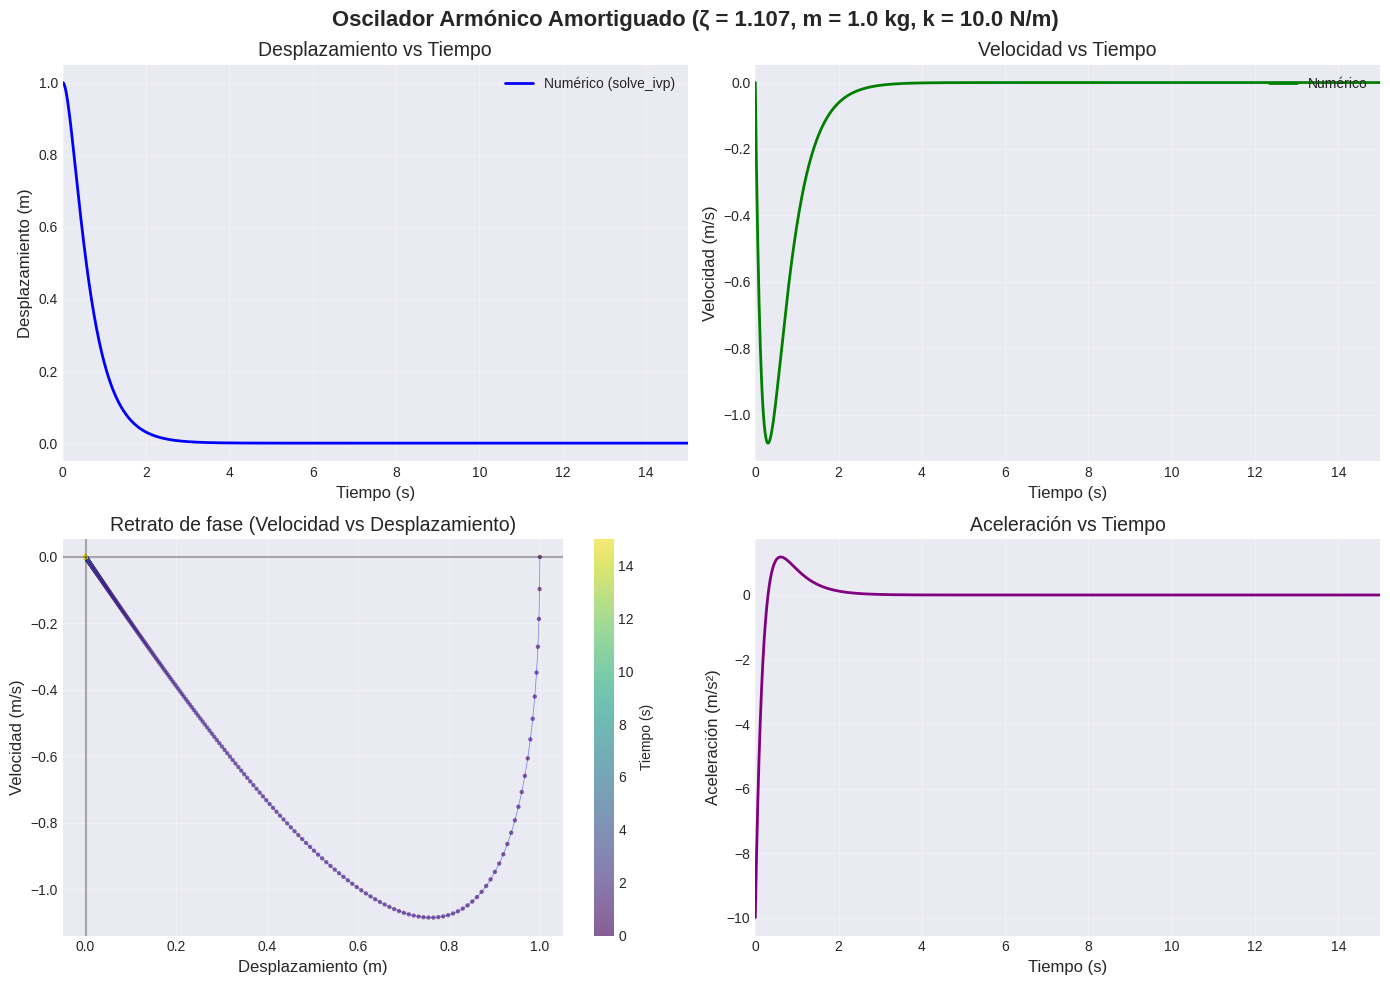

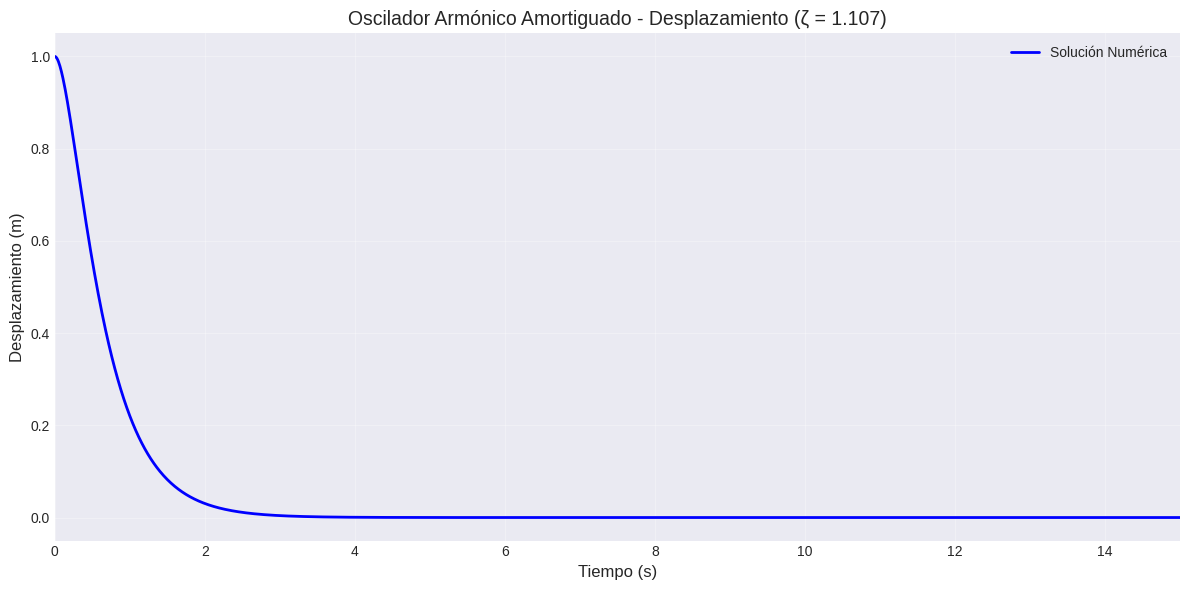


RESUMEN DE CARACTERÍSTICAS DEL SISTEMA
Masa (m): 1.0 kg
Constante del resorte (k): 10.0 N/m
Coeficiente de amortiguamiento (c): 7.0 N·s/m
Frecuencia natural (ω_n): 3.162 rad/s  (f_n = 0.503 Hz)
Razón de amortiguamiento (ζ): 1.107
Desplazamiento inicial: 1.0 m
Velocidad inicial: 0.0 m/s


In [9]:
######################################### Modelo clásico de masa-resorte amortiguado (NO fraccionario) ##########################
# Establecer el estilo de la gráfica
plt.style.use('seaborn-v0_8-darkgrid')

# parámetros físicos 

m  = 1.0    # masa (kg)
k = 10.0   # coeficiente del resorte (N/m)
x1_0 = 1.0 # desplazamiento inicial (m)
x2_0 = 0.0 # velocidad inicial (m/s)
c = 7.0 # coeficiente de amortiguamiento (N*s/m) caso sobreamortiguado

# características del sistema 
nat_freq = np.sqrt(k/m) # frecuencia natural (rad/s)
zeta = c/(2*np.sqrt(m*k)) # razón de amortiguamiento
omega_n = nat_freq

# características del amortiguamiento 
print(f"frecuencia natural (ω_n): {nat_freq:.3f} rads/s")
print(f"razón de amortiguamiento (ζ): {zeta:.3f}")
print(f"Régimen de amortiguamiento: {'Subamortiguado' if zeta < 1 else 'Críticamente amortiguado' if zeta == 1 else 'Sobreamortiguado'}")

# parámetros de tiempo
t_0 = 0.0
t_end = 15
t_points = 100 * t_end
t_eval = np.linspace(t_0, t_end, t_points)

# El sistema se describe mediante: m*x'' + c*x' + k*x = 0  
# donde: x'' = aceleración, x' = velocidad, x = posición

def damped_spring_mass_ode(t, y):
    # Función EDO para el oscilador armónico amortiguado 
    # t : float
    #   Variable de tiempo (no utilizada explícitamente en el sistema autónomo)
    # y : array_like Vector de estado [posición, velocidad]
    # retorna 
    # dydt : list  Derivadas [velocidad, aceleración]
    x1, x2 = y # x1 = posición, x2 = velocidad
    dx1dt = x2
    dx2dt = (-c*x2 - k*x1) / m
    return [dx1dt, dx2dt]

# solución numérica usando solve_ivp
sol = solve_ivp(damped_spring_mass_ode, [t_0, t_end], [x1_0, x2_0], t_eval = t_eval, method='RK45', rtol= 1e-8)
# Solución Numérica: Utiliza solve_ivp con el método de Runge-Kutta-Fehlberg para resolver las ecuaciones exactas.
x1_numerical = sol.y[0] # posición
x2_numerical = sol.y[1] # velocidad 
t_numerical = sol.t

# solución analítica solo para fines comparativos 

if zeta < 1:
    # solución subamortiguada: x(t) = e^(ζω_n t) * [A*cos(ω_n t) + B*sin(ω_n t)]
    nat_freqdamp = nat_freq * np.sqrt(1 - zeta**2) # frecuencia natural amortiguada
    
    # coeficientes determinados a partir de las condiciones iniciales
    A = x1_0 # de x(0) = x1_0
    B = (x2_0 + zeta*nat_freq*x1_0) / nat_freqdamp # x'(0) = x2_0

    # solución analítica de x1
    x1_analytical = np.exp(-zeta*nat_freq*t_numerical) * \
                    (A*np.cos(nat_freqdamp*t_numerical) + B*np.sin(nat_freqdamp*t_numerical))
    
    # solución analítica de x2 para la derivada de la posición (velocidad)
    x2_analytical = np.exp(-zeta*nat_freq*t_numerical) * \
                    (-A*(zeta*nat_freq*np.cos(nat_freqdamp*t_numerical) + nat_freqdamp*np.sin(nat_freqdamp*t_numerical)) + \
                     B*(nat_freqdamp*np.cos(nat_freqdamp*t_numerical) - zeta*nat_freq*np.sin(nat_freqdamp*t_numerical)))


    print(f"Frecuencia natural amortiguada (ω_d): {omega_d:.3f} rad/s")
    print(f"Tasa de decaimiento exponencial: {zeta*omega_n:.3f} 1/s")
    print(f"Periodo de oscilaciones amortiguadas: {2*np.pi/omega_d:.3f} s")
    
# Crear figura con subgráficos
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'Oscilador Armónico Amortiguado (ζ = {zeta:.3f}, m = {m} kg, k = {k} N/m)', 
             fontsize=16, fontweight='bold')

# Gráfico 1: Desplazamiento vs Tiempo (numérico vs analítico)
ax1 = axes[0, 0]
ax1.plot(t_numerical, x1_numerical, 'b-', linewidth=2, label='Numérico (solve_ivp)')
if zeta < 1:
    ax1.plot(t_numerical, x1_analytical, 'r--', linewidth=1.5, alpha=0.7, label='Analítico')
ax1.set_xlabel('Tiempo (s)', fontsize=12)
ax1.set_ylabel('Desplazamiento (m)', fontsize=12)
ax1.set_title('Desplazamiento vs Tiempo', fontsize=14)
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper right')
ax1.set_xlim([t_0, t_end])

# Gráfico 2: Velocidad vs Tiempo
ax2 = axes[0, 1]
ax2.plot(t_numerical, x2_numerical, 'g-', linewidth=2, label='Numérico')
if zeta < 1:
    ax2.plot(t_numerical, x2_analytical, 'r--', linewidth=1.5, alpha=0.7, label='Analítico')
ax2.set_xlabel('Tiempo (s)', fontsize=12)
ax2.set_ylabel('Velocidad (m/s)', fontsize=12)
ax2.set_title('Velocidad vs Tiempo', fontsize=14)
ax2.grid(True, alpha=0.3)
ax2.legend(loc='upper right')
ax2.set_xlim([t_0, t_end])

# Gráfico 3: Retrato de fase (Velocidad vs Desplazamiento)
ax3 = axes[1, 0]
# Codificación por color según el tiempo para una mejor visualización

scatter = ax3.scatter(x1_numerical, x2_numerical, c=t_numerical, cmap='viridis', 
                      s=10, alpha=0.6, edgecolors='none')
ax3.plot(x1_numerical, x2_numerical, 'b-', linewidth=0.5, alpha=0.5)
ax3.set_xlabel('Desplazamiento (m)', fontsize=12)
ax3.set_ylabel('Velocidad (m/s)', fontsize=12)
ax3.set_title('Retrato de fase (Velocidad vs Desplazamiento)', fontsize=14)
ax3.grid(True, alpha=0.3)
ax3.axhline(y=0, color='k', linestyle='-', alpha=0.3)
ax3.axvline(x=0, color='k', linestyle='-', alpha=0.3)
# Agregar barra de color para el tiempo
cbar = plt.colorbar(scatter, ax=ax3)
cbar.set_label('Tiempo (s)', fontsize=10)

# Gráfico 4: Análisis de error (si existe solución analítica) #####
ax4 = axes[1, 1]
if zeta < 1:
    # Calcular el error absoluto entre las soluciones numérica y analítica
    error_position = np.abs(x1_numerical - x1_analytical)
    error_velocity = np.abs(x2_numerical - x2_analytical)
    
    ax4.semilogy(t_numerical, error_position, 'b-', linewidth=1.5, label='Error de posición')
    ax4.semilogy(t_numerical, error_velocity, 'r-', linewidth=1.5, label='Error de velocidad')
    ax4.set_xlabel('Tiempo (s)', fontsize=12)
    ax4.set_ylabel('Error Absoluto (escala log)', fontsize=12)
    ax4.set_title('Análisis de Error Numérico', fontsize=14)
    ax4.grid(True, alpha=0.3)
    ax4.legend(loc='upper right')
    ax4.set_xlim([t_0, t_end])

    
    # Imprimir estadísticas de error    
    print(f"\nEstadísticas de Error:")
    print(f"Error máximo de posición: {np.max(error_position):.2e} m")
    print(f"Error máximo de velocidad: {np.max(error_velocity):.2e} m/s")
    print(f"Error RMS de posición: {np.sqrt(np.mean(error_position**2)):.2e} m")
    print(f"Error RMS de velocidad: {np.sqrt(np.mean(error_velocity**2)):.2e} m/s")
else:
     # Si no es subamortiguado, mostrar el gráfico de aceleración en su lugar
    acceleration = (-c*x2_numerical - k*x1_numerical) / m
    ax4.plot(t_numerical, acceleration, 'purple', linewidth=2)
    ax4.set_xlabel('Tiempo (s)', fontsize=12)
    ax4.set_ylabel('Aceleración (m/s²)', fontsize=12)
    ax4.set_title('Aceleración vs Tiempo', fontsize=14)
    ax4.grid(True, alpha=0.3)
    ax4.set_xlim([t_0, t_end])

plt.tight_layout()
plt.show()

# Gráfico individual adicional para una mejor visualización de las oscilaciones
fig2, ax2_single = plt.subplots(figsize=(12, 6))
if zeta < 1:
    # Gráfico con envolvente para el caso subamortiguado
    envelope = np.exp(-zeta*omega_n*t_numerical) * np.sqrt(A**2 + B**2)
    ax2_single.plot(t_numerical, x1_numerical, 'b-', linewidth=2, label='Solución Numérica')
    ax2_single.plot(t_numerical, envelope, 'r--', linewidth=1, alpha=0.7, label='Envolvente: $e^{-ζω_nt}$')
    ax2_single.plot(t_numerical, -envelope, 'r--', linewidth=1, alpha=0.7)
    ax2_single.fill_between(t_numerical, envelope, -envelope, color='red', alpha=0.1)
else:
    ax2_single.plot(t_numerical, x1_numerical, 'b-', linewidth=2, label='Solución Numérica')


ax2_single.set_xlabel('Tiempo (s)', fontsize=12)
ax2_single.set_ylabel('Desplazamiento (m)', fontsize=12)
ax2_single.set_title(f'Oscilador Armónico Amortiguado - Desplazamiento (ζ = {zeta:.3f})', fontsize=14)
ax2_single.grid(True, alpha=0.3)
ax2_single.legend(loc='upper right')
ax2_single.set_xlim([t_0, t_end])
plt.tight_layout()
plt.show()

# Imprimir resumen de las características del sistema de forma formateada
print("\n" + "="*60)
print("RESUMEN DE CARACTERÍSTICAS DEL SISTEMA")
print("="*60)
print(f"Masa (m): {m} kg")
print(f"Constante del resorte (k): {k} N/m")
print(f"Coeficiente de amortiguamiento (c): {c} N·s/m")
print(f"Frecuencia natural (ω_n): {omega_n:.3f} rad/s  (f_n = {omega_n/(2*np.pi):.3f} Hz)")
print(f"Razón de amortiguamiento (ζ): {zeta:.3f}")
print(f"Desplazamiento inicial: {x1_0} m")
print(f"Velocidad inicial: {x2_0} m/s")


if zeta < 1:
    print(f"\nPARÁMETROS DE OSCILACIÓN SUBAMORTIGUADA:")
    print(f"Frecuencia natural amortiguada (ω_d): {omega_d:.3f} rad/s")
    print(f"Periodo amortiguado (T_d): {2*np.pi/omega_d:.3f} s")
    print(f"Tasa de decaimiento exponencial (σ): {zeta*omega_n:.3f} 1/s")
    print(f"Constante de tiempo de decaimiento (τ): {1/(zeta*omega_n):.3f} s")
    print(f"Factor de calidad (Q): {1/(2*zeta):.3f}")

## Obtención de datos

In [10]:
# Cargar el conjunto de datos desde el archivo CSV
dfover = pd.read_csv('overdamped_data.csv')

# Mostrar las primeras filas para confirmar que se cargó correctamente
print(dfover.head())

   Time (s)  Displacement (m)
0      0.00          1.009934
1      0.01          0.996746
2      0.02          1.011045
3      0.03          1.026263
4      0.04          0.988024


## Carga de datos experimentales y preparación para el modelado conformable

In [11]:
dfover = pd.read_csv('overdamped_data.csv')

# Eliminar t = 0 ya que la derivada fraccionaria no está definida allí
data = dfover[dfover['Time (s)'] > 0].copy()
t_exp = data['Time (s)'].values
x_exp = data['Displacement (m)'].values

print(f"Se cargaron {len(t_exp)} puntos de datos (t > 0)")
print(f"Rango de tiempo: {t_exp[0]:.3f} – {t_exp[-1]:.3f} s")

# Condiciones iniciales a partir de los datos
x1_0_data = x_exp[0]                # primer desplazamiento medido
# Estimar la velocidad inicial a partir de los primeros dos puntos (diferencia hacia adelante)
dt_data = t_exp[1] - t_exp[0]
x2_0_data = (x_exp[1] - x_exp[0]) / dt_data

print(f"Desplazamiento inicial a partir de los datos: {x1_0_data:.6f} m")
print(f"Velocidad inicial estimada: {x2_0_data:.6f} m/s")

# Intervalo de tiempo para la integración (debe comenzar en > 0)
t_span = (t_exp[0], t_exp[-1])
y0 = [x1_0_data, x2_0_data]

Se cargaron 2000 puntos de datos (t > 0)
Rango de tiempo: 0.010 – 20.000 s
Desplazamiento inicial a partir de los datos: 0.996746 m
Velocidad inicial estimada: 1.429834 m/s


## Modelo conformable con $\alpha \to 1$

Establecemos $\alpha$ en un valor extremadamente cercano a 1 ($0.99999$) y comparamos el resultado con el modelo clásico. La diferencia debería ser mínima, lo que confirma que la implementación conformable es correcta.

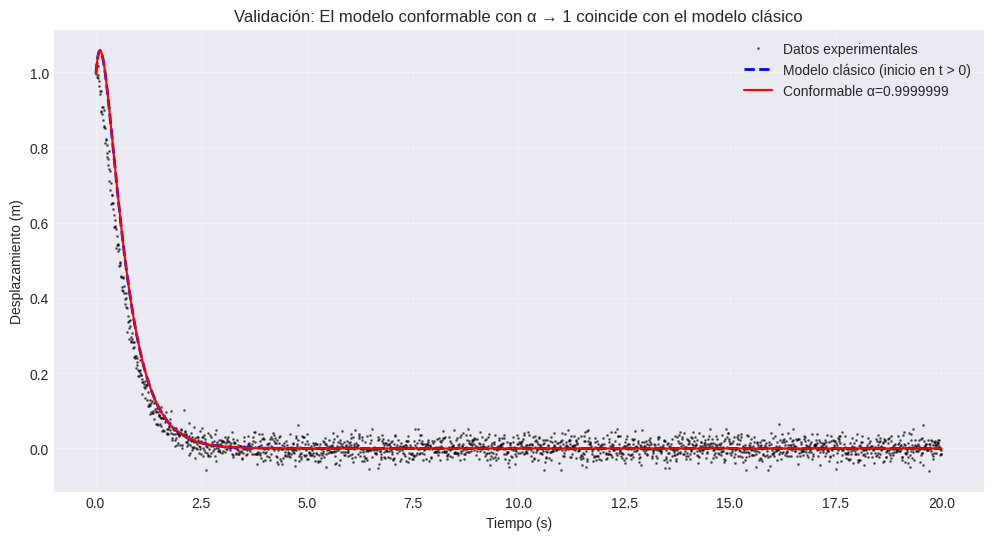

Diferencia máxima entre el modelo conformable α → 1 y el clásico: 8.81e-08


In [12]:
# MODELO CLÁSICO (para comparación)
# Debemos definir sol_classical resolviendo la EDO clásica sobre el mismo intervalo de tiempo (t_span) 
# y evaluando exactamente en los mismos puntos (t_exp) que el modelo conformable.
sol_classical = solve_ivp(damped_spring_mass_ode, t_span, [x1_0_data, x2_0_data],
                          t_eval=t_exp, method='RK45', rtol=1e-8)

# MODELO FRACCIONARIO CONFORMABLE (con α muy cercano a 1) para verificar la implementación
alpha_near_one = 0.9999999

def conformable_ode_near_one(t, y):
    """EDO de la derivada conformable con α ≈ 1 – debería reproducir el resultado clásico."""
    x, v = y
    # Factor de escalamiento t^(α-1) – cuando α ≈ 1 es muy cercano a 1, pero no exactamente.
    scale = t ** (alpha_near_one - 1)
    dxdt = scale * v
    dvdt = scale * (-c * v - k * x) / m
    return [dxdt, dvdt]

# Resolver con las mismas condiciones iniciales que el modelo clásico
sol_near_one = solve_ivp(conformable_ode_near_one, t_span, [x1_0_data, x2_0_data],
                         t_eval=t_exp, method='RK45', rtol=1e-8)

# Graficar 
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(t_exp, x_exp, 'k.', markersize=2, alpha=0.5, label='Datos experimentales')
ax.plot(sol_classical.t, sol_classical.y[0], 'b--', linewidth=2, label='Modelo clásico (inicio en t > 0)')
ax.plot(sol_near_one.t, sol_near_one.y[0], 'r-', linewidth=1.5, label=f'Conformable α={alpha_near_one}')
ax.set_xlabel('Tiempo (s)')
ax.set_ylabel('Desplazamiento (m)')
ax.set_title('Validación: El modelo conformable con α → 1 coincide con el modelo clásico')
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

# Calcular la diferencia para verificar la identidad casi exacta
# Dado que ambos solvers usan t_eval=t_exp, sus arreglos de salida tienen la misma longitud
max_diff = np.max(np.abs(sol_near_one.y[0] - sol_classical.y[0]))
print(f"Diferencia máxima entre el modelo conformable α → 1 y el clásico: {max_diff:.2e}")

## Modelo conformable con $\sigma$

In [13]:
# MODELO FRACCIONARIO CON ESCALAMIENTO DIMENSIONAL σ
def fractional_model(params, t_eval):
    """
    Resuelve el oscilador amortiguado fraccionario para valores dados de α y σ.
    
    Parámetros
    ----------
    params : list
        [alpha, sigma]  (sigma en segundos)
    t_eval : array
        Tiempos en los que se evalúa la solución (debe ser > 0)
    
    Retorna
    -------
    x : array
        Desplazamiento en t_eval
    """
    alpha, sigma = params
    
    # Restricciones físicas – devuelve un error enorme si los parámetros no son válidos
    if alpha <= 0 or alpha > 1 or sigma <= 0:
        return np.ones_like(t_eval) * 1e6
    
    def ode(t, y):
        x, v = y
        # Factor de escalamiento dimensional (t/σ)^(α-1)
        scale = (t / sigma) ** (alpha - 1)
        dxdt = scale * v
        dvdt = scale * (-c * v - k * x) / m
        return [dxdt, dvdt]
    
    try:
        sol = solve_ivp(ode, t_span, y0, t_eval=t_eval,
                        method='RK45', rtol=1e-8, atol=1e-10)
        if sol.success:
            return sol.y[0]
        else:
            return np.ones_like(t_eval) * 1e6
    except:
        return np.ones_like(t_eval) * 1e6

### Función objetivo para realizar la optimización

In [14]:
def objective(params):
    """MSE entre el modelo fraccionario y los datos experimentales."""
    x_sim = fractional_model(params, t_exp)
    mse = np.mean((x_sim - x_exp) ** 2)
    return mse

In [15]:
tau_0 = np.sqrt(m / k)   # ≈ 0.316 s

# límites de α: [0.9, 1.0] (orden fraccionario, efectos de memoria) también hemos aprendido que un alfa con significancia real caerá en dichos límites
alpha_bounds = (0.9, 0.999)

# límites de σ: dentro de un orden de magnitud de τ₀
sigma_bounds = (0.1 * tau_0, 100 * tau_0)   # (0.0316, 31.62) s

bounds = [alpha_bounds, sigma_bounds]

# Estimación inicial: α cercano a 1, σ en 10*tau_0; sabemos que es un sistema diferente y los parámetros serán distintos, pero como sigue las mismas ecuaciones tendrá σ como el último optimizado
initial_guess = [0.95, 10*tau_0]

print("Estimación inicial:")
print(f"  α = {initial_guess[0]:.3f}")
print(f"  σ = {initial_guess[1]:.3f} s")
print("\nLímites:")
print(f"  α ∈ [{alpha_bounds[0]:.3f}, {alpha_bounds[1]:.3f}]")
print(f"  σ ∈ [{sigma_bounds[0]:.3f}, {sigma_bounds[1]:.3f}] s")

Estimación inicial:
  α = 0.950
  σ = 3.162 s

Límites:
  α ∈ [0.900, 0.999]
  σ ∈ [0.032, 31.623] s


## Optimización multietapa

In [16]:
print("OPTIMIZACIÓN MULTIETAPA")
print("="*70)

best_params = None
best_mse = float('inf')

# Etapa 1: Búsqueda global (evolución diferencial)
print("\nEtapa 1: Búsqueda global (evolución diferencial) ...")
try:
    result_global = differential_evolution(
        objective,
        bounds,
        strategy='best1bin',
        maxiter=50,
        popsize=10,
        recombination=0.7,
        mutation=(0.5, 1.0),
        tol=1e-4,
        disp=True,
        seed=42,
        workers=1,
        updating='immediate'
    )
    
    print(f"\nResultado global: α = {result_global.x[0]:.6f}, σ = {result_global.x[1]:.6f} s, MSE = {result_global.fun:.6e}")
    best_params = result_global.x
    best_mse = result_global.fun
except Exception as e:
    print(f"La búsqueda global falló: {e}")
    best_params = initial_guess
    best_mse = objective(initial_guess)

# Etapa 2: Refinamiento local con Nelder‑Mead (respeta los límites mediante penalizaciones en la función objetivo)
print("\nEtapa 2: Refinamiento local (Nelder‑Mead) ...")
try:
    result_nm = minimize(
        objective,
        best_params,
        method='Nelder-Mead',
        bounds=bounds,
        options={'maxiter': 200, 'xatol': 1e-6, 'fatol': 1e-6, 'adaptive': True}
    )
    if result_nm.fun < best_mse:
        best_params = result_nm.x
        best_mse = result_nm.fun
    print(f"  α = {best_params[0]:.6f}, σ = {best_params[1]:.6f} s, MSE = {best_mse:.6e}")
except Exception as e:
    print(f"Nelder‑Mead falló: {e}")

# Etapa 3: Ajuste fino con L‑BFGS‑B (basado en gradiente, respeta los límites)
print("\nEtapa 3: Ajuste fino (L‑BFGS‑B) ...")
try:
    result_lbfgs = minimize(
        objective,
        best_params,
        method='L-BFGS-B',
        bounds=bounds,
        options={'maxiter': 100, 'ftol': 1e-10, 'gtol': 1e-8, 'eps': 1e-8}
    )
    if result_lbfgs.fun < best_mse:
        best_params = result_lbfgs.x
        best_mse = result_lbfgs.fun
    print(f"  α = {best_params[0]:.6f}, σ = {best_params[1]:.6f} s, MSE = {best_mse:.6e}")
except Exception as e:
    print(f"L‑BFGS‑B falló: {e}")

print("\n" + "="*70)
print(f"PARÁMETROS OPTIMIZADOS")
print(f"  α = {best_params[0]:.6f}")
print(f"  σ = {best_params[1]:.6f} s")
print(f"  MSE mínimo = {best_mse:.6e}")
print("="*70)

OPTIMIZACIÓN MULTIETAPA

Etapa 1: Búsqueda global (evolución diferencial) ...
differential_evolution step 1: f(x)= 0.0005784228839506361
differential_evolution step 2: f(x)= 0.0005588421988869797
differential_evolution step 3: f(x)= 0.0005496476873038006
differential_evolution step 4: f(x)= 0.0005314992904093652
differential_evolution step 5: f(x)= 0.0005314992904093652
differential_evolution step 6: f(x)= 0.0005271405527523163
differential_evolution step 7: f(x)= 0.0005271405527523163
differential_evolution step 8: f(x)= 0.0005271405527523163
differential_evolution step 9: f(x)= 0.0005271405527523163
differential_evolution step 10: f(x)= 0.0005271405527523163
differential_evolution step 11: f(x)= 0.0005271405527523163
differential_evolution step 12: f(x)= 0.0005244661043891092
differential_evolution step 13: f(x)= 0.0005243741184479306
differential_evolution step 14: f(x)= 0.0005243741184479306
differential_evolution step 15: f(x)= 0.0005240799243621537
differential_evolution step 16:

## Graficación del ajuste optimizado vs. datos sintéticos

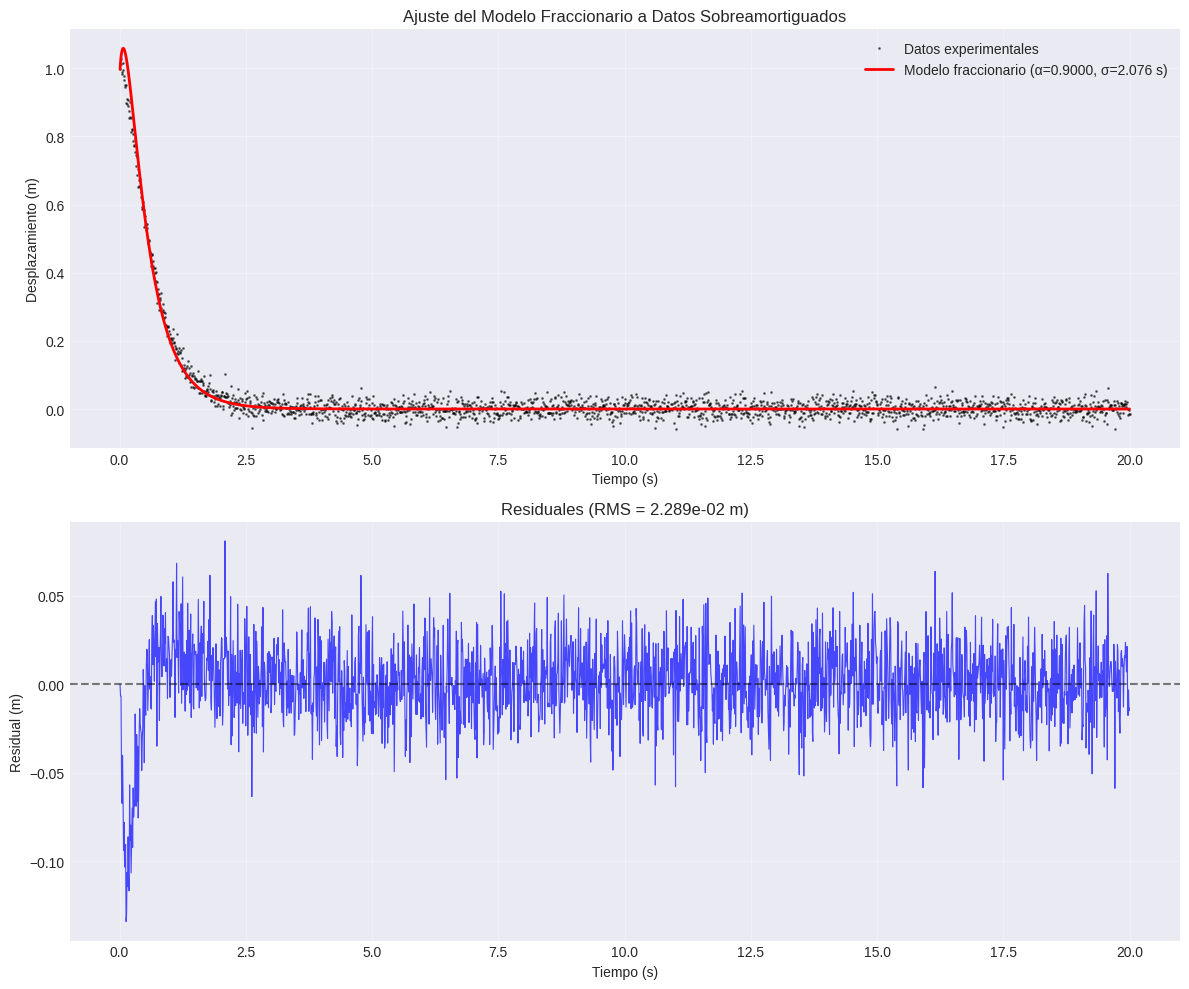

In [17]:
x_opt = fractional_model(best_params, t_exp)

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Superior: serie temporal
ax = axes[0]
ax.plot(t_exp, x_exp, 'k.', markersize=2, alpha=0.5, label='Datos experimentales')
ax.plot(t_exp, x_opt, 'r-', linewidth=2, label=f'Modelo fraccionario (α={best_params[0]:.4f}, σ={best_params[1]:.3f} s)')
ax.set_xlabel('Tiempo (s)')
ax.set_ylabel('Desplazamiento (m)')
ax.set_title('Ajuste del Modelo Fraccionario a Datos Sobreamortiguados')
ax.grid(True, alpha=0.3)
ax.legend()

# Inferior: residuales
ax = axes[1]
residuals = x_exp - x_opt
ax.plot(t_exp, residuals, 'b-', linewidth=0.8, alpha=0.7)
ax.axhline(y=0, color='k', linestyle='--', alpha=0.5)
ax.set_xlabel('Tiempo (s)')
ax.set_ylabel('Residual (m)')
ax.set_title(f'Residuales (RMS = {np.sqrt(np.mean(residuals**2)):.3e} m)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Perfil de verosimilitud para $\sigma$

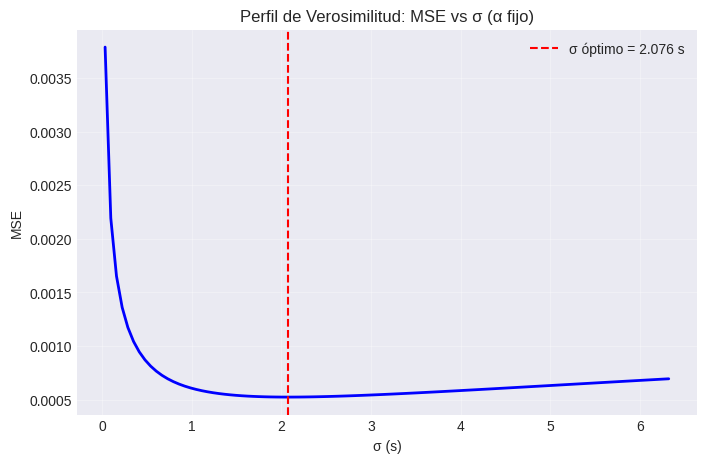

In [18]:
# Fijar α en el óptimo, variar σ y calcular el MSE
alpha_fixed = best_params[0]
sigma_test = np.linspace(0.1*tau_0, 20*tau_0, 100)
mse_sigma = [objective([alpha_fixed, s]) for s in sigma_test]

fig, ax = plt.subplots(figsize=(8,5))
ax.plot(sigma_test, mse_sigma, 'b-', linewidth=2)
ax.axvline(best_params[1], color='r', linestyle='--', label=f'σ óptimo = {best_params[1]:.3f} s')
ax.set_xlabel('σ (s)')
ax.set_ylabel('MSE')
ax.set_title('Perfil de Verosimilitud: MSE vs σ (α fijo)')
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()